# 資料集檢閱

## 一、北京 PRSA 多站點空氣品質資料（縱向合併）
## 二、印度 AQI 資料集（aqi_india_38cols_knn_final.csv）
## 三、台灣空氣品質資料集（air_quality.csv）
## 四、三資料集標準化（Unified Schema）

In [1]:
import pandas as pd
import glob, os

datasets = {
    "PRSA（北京，合併）": pd.concat(
        [pd.read_csv(f) for f in sorted(glob.glob(
            "beijing+multi+site+air+quality+data/PRSA_Data_20130301-20170228/*.csv"))],
        ignore_index=True
    ),
    "India AQI":  pd.read_csv("archive/aqi_india_38cols_knn_final.csv"),
    "Taiwan AQI": pd.read_csv("air_quality.csv"),
}

for name, df in datasets.items():
    print(f"{'='*60}")
    print(f"【{name}】  shape={df.shape}")
    print(f"  欄位數：{len(df.columns)}")
    for i, col in enumerate(df.columns):
        print(f"  {i:>3}. {col}")
    print()

/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_13609/2869799364.py:11: DtypeWarning: Columns (6,7,8,9,10,11,12,13,14,15,16,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  "Taiwan AQI": pd.read_csv("air_quality.csv"),


【PRSA（北京，合併）】  shape=(420768, 18)
  欄位數：18
    0. No
    1. year
    2. month
    3. day
    4. hour
    5. PM2.5
    6. PM10
    7. SO2
    8. NO2
    9. CO
   10. O3
   11. TEMP
   12. PRES
   13. DEWP
   14. RAIN
   15. wd
   16. WSPM
   17. station

【India AQI】  shape=(842160, 31)
  欄位數：31
    0. city
    1. state
    2. latitude
    3. longitude
    4. datetime
    5. month
    6. day_name
    7. is_weekend
    8. season
    9. time_of_day
   10. humidity_percent
   11. dew_point_c
   12. wind_gusts_kmh
   13. precipitation_mm
   14. is_raining
   15. heavy_rain
   16. pressure_msl_hpa
   17. cloud_cover_percent
   18. pm2_5_ugm3
   19. pm10_ugm3
   20. co_ugm3
   21. no2_ugm3
   22. so2_ugm3
   23. o3_ugm3
   24. dust_ugm3
   25. aod
   26. us_aqi
   27. aqi_category
   28. pm25_category_india
   29. festival_period
   30. crop_burning_season

【Taiwan AQI】  shape=(5882208, 25)
  欄位數：25
    0. date
    1. sitename
    2. county
    3. aqi
    4. pollutant
    5. status
    6. so2


---
## 一、北京 PRSA 多站點空氣品質資料（縱向合併）

In [2]:
import pandas as pd
import glob
import os

prsa_dir = "beijing+multi+site+air+quality+data/PRSA_Data_20130301-20170228"
csv_files = sorted(glob.glob(os.path.join(prsa_dir, "*.csv")))

print(f"找到 {len(csv_files)} 個 CSV 檔：")
for f in csv_files:
    print(" ", os.path.basename(f))

找到 12 個 CSV 檔：
  PRSA_Data_Aotizhongxin_20130301-20170228.csv
  PRSA_Data_Changping_20130301-20170228.csv
  PRSA_Data_Dingling_20130301-20170228.csv
  PRSA_Data_Dongsi_20130301-20170228.csv
  PRSA_Data_Guanyuan_20130301-20170228.csv
  PRSA_Data_Gucheng_20130301-20170228.csv
  PRSA_Data_Huairou_20130301-20170228.csv
  PRSA_Data_Nongzhanguan_20130301-20170228.csv
  PRSA_Data_Shunyi_20130301-20170228.csv
  PRSA_Data_Tiantan_20130301-20170228.csv
  PRSA_Data_Wanliu_20130301-20170228.csv
  PRSA_Data_Wanshouxigong_20130301-20170228.csv


In [3]:
df_prsa = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

print("=== PRSA 合併後基本資訊 ===")
print(f"形狀（rows × cols）：{df_prsa.shape}")
print(f"\n各站點筆數：")
print(df_prsa["station"].value_counts())
print(f"\n時間範圍：{df_prsa['year'].min()}-{df_prsa['month'].min():02d} ～ {df_prsa['year'].max()}-{df_prsa['month'].max():02d}")

=== PRSA 合併後基本資訊 ===
形狀（rows × cols）：(420768, 18)

各站點筆數：
station
Aotizhongxin     35064
Changping        35064
Dingling         35064
Dongsi           35064
Guanyuan         35064
Gucheng          35064
Huairou          35064
Nongzhanguan     35064
Shunyi           35064
Tiantan          35064
Wanliu           35064
Wanshouxigong    35064
Name: count, dtype: int64

時間範圍：2013-01 ～ 2017-12


In [4]:
print("=== 前 5 筆 ===")
display(df_prsa.head())

print("\n=== 後 5 筆 ===")
display(df_prsa.tail())

=== 前 5 筆 ===


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin



=== 後 5 筆 ===


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
420763,35060,2017,2,28,19,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Wanshouxigong
420764,35061,2017,2,28,20,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Wanshouxigong
420765,35062,2017,2,28,21,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,NW,1.1,Wanshouxigong
420766,35063,2017,2,28,22,12.0,23.0,4.0,30.0,400.0,59.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Wanshouxigong
420767,35064,2017,2,28,23,13.0,19.0,4.0,38.0,600.0,49.0,8.6,1014.1,-15.9,0.0,NNE,1.3,Wanshouxigong


In [5]:
print("=== 資料型態 ===")
print(df_prsa.dtypes)

print("\n=== 缺失值統計 ===")
missing = df_prsa.isnull().sum()
missing_pct = (missing / len(df_prsa) * 100).round(2)
print(pd.DataFrame({"缺失筆數": missing, "缺失率(%)": missing_pct})[missing > 0])

print("\n=== 數值欄位描述統計 ===")
display(df_prsa.describe())

=== 資料型態 ===
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object

=== 缺失值統計 ===
        缺失筆數  缺失率(%)
PM2.5   8739    2.08
PM10    6449    1.53
SO2     9021    2.14
NO2    12116    2.88
CO     20701    4.92
O3     13277    3.16
TEMP     398    0.09
PRES     393    0.09
DEWP     403    0.10
RAIN     390    0.09
wd      1822    0.43
WSPM     318    0.08

=== 數值欄位描述統計 ===


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


---
## 二、印度 AQI 資料集（aqi_india_38cols_knn_final.csv）

In [6]:
df_india = pd.read_csv("archive/aqi_india_38cols_knn_final.csv")

print("=== 印度 AQI 基本資訊 ===")
print(f"形狀（rows × cols）：{df_india.shape}")
print(f"\n城市數：{df_india['city'].nunique()}，州數：{df_india['state'].nunique()}")
print(f"時間範圍：{df_india['datetime'].min()} ～ {df_india['datetime'].max()}")

=== 印度 AQI 基本資訊 ===
形狀（rows × cols）：(842160, 31)

城市數：29，州數：29
時間範圍：2022-08-05 00:00:00 ～ 2025-11-26 23:00:00


In [7]:
display(df_india.head())

print("\n=== 缺失值統計 ===")
missing_india = df_india.isnull().sum()
missing_india_pct = (missing_india / len(df_india) * 100).round(2)
summary = pd.DataFrame({"缺失筆數": missing_india, "缺失率(%)": missing_india_pct})
print(summary[missing_india > 0] if missing_india.any() else "無缺失值")

print("\n=== 數值欄位描述統計 ===")
display(df_india.describe())

,city,state,latitude,longitude,datetime,month,day_name,is_weekend,season,time_of_day,...,no2_ugm3,so2_ugm3,o3_ugm3,dust_ugm3,aod,us_aqi,aqi_category,pm25_category_india,festival_period,crop_burning_season
0,agartala,tripura,23.8315,91.2868,2022-08-05 00:00:00,8.0,friday,False,monsoon,night,...,21.8,2.7,32.0,0.0,0.14,289.0,Very Unhealthy,good,False,False
1,agartala,tripura,23.8315,91.2868,2022-08-05 01:00:00,8.0,friday,False,monsoon,night,...,18.5,3.0,33.0,0.0,0.14,289.0,Very Unhealthy,good,False,False
2,agartala,tripura,23.8315,91.2868,2022-08-05 02:00:00,8.0,friday,False,monsoon,night,...,15.1,3.3,34.0,0.0,0.15,54.0,Moderate,good,False,False
3,agartala,tripura,23.8315,91.2868,2022-08-05 03:00:00,8.0,friday,False,monsoon,night,...,14.1,3.3,32.0,0.0,0.15,54.0,Moderate,good,False,False
4,agartala,tripura,23.8315,91.2868,2022-08-05 04:00:00,8.0,friday,False,monsoon,night,...,13.9,3.2,30.0,0.0,0.14,54.0,Moderate,good,False,False



=== 缺失值統計 ===
                     缺失筆數  缺失率(%)
pm25_category_india     2     0.0

=== 數值欄位描述統計 ===


,latitude,longitude,month,humidity_percent,dew_point_c,wind_gusts_kmh,precipitation_mm,pressure_msl_hpa,cloud_cover_percent,pm2_5_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,so2_ugm3,o3_ugm3,dust_ugm3,aod,us_aqi
count,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.00000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000,842160.000000
mean,23.129041,82.769207,6.801653,71.324796,17.160777,19.270394,0.197799,1009.489776,50.50123,34.549825,54.014723,444.932728,15.991785,13.390032,80.188893,19.856400,0.463936,94.712182
std,5.543478,6.937205,3.411504,21.362100,7.020427,9.921461,0.915802,5.698795,43.41348,29.652013,54.231554,377.007222,19.896299,18.921014,44.762719,72.359802,0.299889,47.234756
min,8.524100,72.571400,1.000000,3.000000,-11.500000,3.200000,0.000000,979.400000,0.00000,1.900000,2.300000,96.000000,0.000000,0.200000,0.000000,0.000000,0.050000,19.000000
25%,20.296100,77.173400,4.000000,58.000000,12.100000,11.500000,0.000000,1005.400000,2.00000,14.700000,21.500000,235.000000,3.700000,2.800000,47.000000,0.000000,0.240000,59.000000
50%,23.831500,80.946200,7.000000,76.000000,18.600000,17.300000,0.000000,1009.900000,47.00000,25.900000,39.000000,333.000000,9.000000,6.900000,73.000000,2.000000,0.400000,84.000000
75%,26.912400,88.606500,10.000000,89.000000,23.300000,25.200000,0.000000,1013.800000,100.00000,44.200000,66.400000,508.000000,19.900000,15.800000,108.000000,11.000000,0.610000,128.000000
max,31.104800,94.108600,12.000000,100.000000,27.300000,55.100000,51.700000,1028.100000,100.00000,183.500000,420.000000,2903.000000,122.100000,134.200000,228.000000,714.000000,1.700000,289.000000


In [8]:
print("=== AQI 類別分布 ===")
print(df_india["aqi_category"].value_counts())

print("\n=== 前 10 大城市筆數 ===")
print(df_india["city"].value_counts().head(10))

=== AQI 類別分布 ===
aqi_category
Moderate                          385833
Unhealthy for Sensitive Groups    175125
Good                              136476
Unhealthy                         130360
Very Unhealthy                     14366
Name: count, dtype: int64

=== 前 10 大城市筆數 ===
city
agartala              29040
itanagar              29040
thiruvananthapuram    29040
shimla                29040
shillong              29040
ranchi                29040
raipur                29040
patna                 29040
panaji                29040
mumbai                29040
Name: count, dtype: int64


---
## 三、台灣空氣品質資料集（air_quality.csv）

In [9]:
df_tw = pd.read_csv("air_quality.csv")

print("=== 台灣空氣品質基本資訊 ===")
print(f"形狀（rows × cols）：{df_tw.shape}")
print(f"\n欄位：{list(df_tw.columns)}")
print(f"\n監測站數：{df_tw['sitename'].nunique()}")
print(f"縣市數：{df_tw['county'].nunique()}")
print(f"時間範圍：{df_tw['date'].min()} ～ {df_tw['date'].max()}")

/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_13609/4240663605.py:1: DtypeWarning: Columns (6,7,8,9,10,11,12,13,14,15,16,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tw = pd.read_csv("air_quality.csv")


=== 台灣空氣品質基本資訊 ===
形狀（rows × cols）：(5882208, 25)

欄位：['date', 'sitename', 'county', 'aqi', 'pollutant', 'status', 'so2', 'co', 'o3', 'o3_8hr', 'pm10', 'pm2.5', 'no2', 'nox', 'no', 'windspeed', 'winddirec', 'unit', 'co_8hr', 'pm2.5_avg', 'pm10_avg', 'so2_avg', 'longitude', 'latitude', 'siteid']

監測站數：123
縣市數：22
時間範圍：2016-11-25 13:00 ～ 2024-08-31 23:00


In [10]:
display(df_tw.head())

print("\n=== 缺失值統計 ===")
missing_tw = df_tw.isnull().sum()
missing_tw_pct = (missing_tw / len(df_tw) * 100).round(2)
summary_tw = pd.DataFrame({"缺失筆數": missing_tw, "缺失率(%)": missing_tw_pct})
print(summary_tw[missing_tw > 0] if missing_tw.any() else "無缺失值")

print("\n=== 數值欄位描述統計 ===")
display(df_tw.describe())

,date,sitename,county,aqi,pollutant,status,so2,co,o3,o3_8hr,...,windspeed,winddirec,unit,co_8hr,pm2.5_avg,pm10_avg,so2_avg,longitude,latitude,siteid
0,2024-08-31 23:00,Hukou,Hsinchu County,62.0,PM2.5,Moderate,0.9,0.17,35.0,40.2,...,2.3,225,NaN,0.2,20.1,26.0,1.0,121.038869,24.900097,22.0
1,2024-08-31 23:00,Zhongming,Taichung City,50.0,NaN,Good,1.6,0.32,27.9,35.1,...,1.1,184,NaN,0.2,15.3,23.0,1.0,120.641092,24.151958,31.0
2,2024-08-31 23:00,Zhudong,Hsinchu County,45.0,NaN,Good,0.4,0.17,25.1,40.6,...,0.4,210,NaN,0.2,13.8,24.0,0.0,121.088955,24.740914,23.0
3,2024-08-31 23:00,Hsinchu,Hsinchu City,42.0,NaN,Good,0.8,0.2,30.0,35.9,...,1.9,239,NaN,0.2,13.0,26.0,1.0,120.972368,24.805636,24.0
4,2024-08-31 23:00,Toufen,Miaoli County,50.0,NaN,Good,1.0,0.16,33.5,35.9,...,1.8,259,NaN,0.1,15.3,28.0,1.0,120.898693,24.696907,25.0



=== 缺失值統計 ===
              缺失筆數  缺失率(%)
aqi          43020    0.73
pollutant  3235012   55.00
status      142718    2.43
so2         139768    2.38
co          113504    1.93
o3          125017    2.13
o3_8hr      131081    2.23
pm10        140358    2.39
pm2.5       131438    2.23
no2         165977    2.82
nox         169124    2.88
no          169455    2.88
windspeed   219498    3.73
winddirec   219736    3.74
unit       5882208  100.00
co_8hr       81229    1.38
pm2.5_avg    79941    1.36
pm10_avg     89875    1.53
so2_avg     629162   10.70
longitude   933620   15.87
latitude    933620   15.87
siteid     1779469   30.25

=== 數值欄位描述統計 ===


,aqi,unit,longitude,latitude,siteid
count,5.839188e+06,0.0,4.948588e+06,4.948588e+06,4.102739e+06
mean,5.419277e+01,NaN,1.208235e+02,2.404500e+01,5.608608e+01
std,2.985864e+01,NaN,9.644120e-01,1.002014e+00,6.233482e+01
min,-1.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.200000e+01,NaN,1.203455e+02,2.304820e+01,2.100000e+01
50%,4.600000e+01,NaN,1.206853e+02,2.415196e+01,4.200000e+01
75%,7.000000e+01,NaN,1.214492e+02,2.501297e+01,6.500000e+01
max,5.000000e+02,NaN,1.218157e+02,2.625800e+01,3.140000e+02


In [11]:
print("=== AQI 狀態分布 ===")
print(df_tw["status"].value_counts())

print("\n=== 主要污染物分布 ===")
print(df_tw["pollutant"].value_counts())

print("\n=== 前 10 大監測站筆數 ===")
print(df_tw["sitename"].value_counts().head(10))

=== AQI 狀態分布 ===
status
Good                              3185191
Moderate                          2159158
Unhealthy for Sensitive Groups     343909
Unhealthy                           51008
Very Unhealthy                        173
Hazardous                              51
Name: count, dtype: int64

=== 主要污染物分布 ===
pollutant
PM2.5                     2296437
Ozone (8hr)                250979
PM10                        75230
Nitrogen Dioxide (NO2)      23951
Sulfur Dioxide (SO2)          497
Ozone                         100
Carbon Monoxide (CO)            2
Name: count, dtype: int64

=== 前 10 大監測站筆數 ===
sitename
Yangming     72180
Tamsui       72173
Shilin       71944
Zhongshan    71943
Dayuan       71942
Pingzhen     71935
Datong       71934
Hsinchu      71932
Wanli        71928
Zhudong      71928
Name: count, dtype: int64


---
## 四、三資料集標準化（Unified Schema）

**目標**：對齊研究框架 Section 3.1 Unified Feature Projector，統一欄位名稱、單位與格式。

In [12]:
import numpy as np

# 統一欄位順序
UNIFIED_COLS = [
    "datetime", "year", "month", "day", "hour", "season",
    "station", "latitude", "longitude", "source",
    "pm25", "pm10", "o3", "no2",
    "temperature", "humidity", "wind_speed", "wind_dir",
    "pm25_exceed",
]

# 北京各站經緯度（官方公開座標）
PRSA_COORDS = {
    "Aotizhongxin":  (39.9829, 116.3972),
    "Changping":     (40.2174, 116.2316),
    "Dingling":      (40.2918, 116.1701),
    "Dongsi":        (39.9289, 116.4173),
    "Guanyuan":      (39.9293, 116.3392),
    "Gucheng":       (39.9141, 116.1843),
    "Huairou":       (40.3282, 116.6286),
    "Nongzhanguan":  (39.9374, 116.4614),
    "Shunyi":        (40.1281, 116.6542),
    "Tiantan":       (39.8864, 116.4072),
    "Wanliu":        (39.9874, 116.2950),
    "Wanshouxigong": (39.8782, 116.3522),
}

# 風向文字 → 角度
WD_DEG = {
    "N": 0.0, "NNE": 22.5, "NE": 45.0,  "ENE": 67.5,
    "E": 90.0,"ESE":112.5, "SE":135.0,  "SSE":157.5,
    "S":180.0,"SSW":202.5, "SW":225.0,  "WSW":247.5,
    "W":270.0,"WNW":292.5, "NW":315.0,  "NNW":337.5,
}

def season_from_month(m):
    if m in [3, 4, 5]:   return 0  # 春
    if m in [6, 7, 8]:   return 1  # 夏
    if m in [9, 10, 11]: return 2  # 秋
    return 3                        # 冬

def rh_from_temp_dewp(T, Td):
    """Magnus formula: RH(%) from temperature T and dew point Td (°C)"""
    return 100 * np.exp((17.625 * Td) / (243.04 + Td)) / \
                 np.exp((17.625 * T)  / (243.04 + T))

print("UNIFIED_COLS:", UNIFIED_COLS)
print("輔助函式 ready ✓")

UNIFIED_COLS: ['datetime', 'year', 'month', 'day', 'hour', 'season', 'station', 'latitude', 'longitude', 'source', 'pm25', 'pm10', 'o3', 'no2', 'temperature', 'humidity', 'wind_speed', 'wind_dir', 'pm25_exceed']
輔助函式 ready ✓


In [13]:
# ── 北京 PRSA 處理 ────────────────────────────────────────
df_b = df_prsa.copy()

# 轉換時間與生成輔助特徵
df_b["datetime"]    = pd.to_datetime(df_b[["year", "month", "day", "hour"]])
df_b["season"]      = df_b["month"].apply(season_from_month)
df_b["latitude"]    = df_b["station"].map(lambda s: PRSA_COORDS.get(s, (np.nan, np.nan))[0])
df_b["longitude"]   = df_b["station"].map(lambda s: PRSA_COORDS.get(s, (np.nan, np.nan))[1])
df_b["source"]      = "beijing"
df_b["humidity"]    = rh_from_temp_dewp(df_b["TEMP"], df_b["DEWP"])
df_b["wind_dir"]    = df_b["wd"].map(WD_DEG)
df_b["pm25_exceed"] = (df_b["PM2.5"] > 35.4).astype(float)

# 重命名欄位並選取統一格式欄位 (UNIFIED_COLS)
df_beijing = df_b.rename(columns={
    "PM2.5": "pm25", "PM10": "pm10", "O3": "o3", "NO2": "no2",
    "TEMP": "temperature", "WSPM": "wind_speed",
})[UNIFIED_COLS]

print(f"Beijing 處理完成：{df_beijing.shape}")
print(f"pm25 範圍：{df_beijing['pm25'].min():.1f} ~ {df_beijing['pm25'].max():.1f} μg/m³")
print(f"超標率：{df_beijing['pm25_exceed'].mean()*100:.1f}%")
display(df_beijing.head(3))

Beijing 處理完成：(420768, 19)
pm25 範圍：2.0 ~ 999.0 μg/m³
超標率：61.4%


,datetime,year,month,day,hour,season,station,latitude,longitude,source,pm25,pm10,o3,no2,temperature,humidity,wind_speed,wind_dir,pm25_exceed
0,2013-03-01 00:00:00,2013,3,1,0,0,Aotizhongxin,39.9829,116.3972,beijing,4.0,4.0,77.0,7.0,-0.7,24.008842,4.4,337.5,0.0
1,2013-03-01 01:00:00,2013,3,1,1,0,Aotizhongxin,39.9829,116.3972,beijing,8.0,8.0,77.0,7.0,-1.1,26.013678,4.7,0.0,0.0
2,2013-03-01 02:00:00,2013,3,1,2,0,Aotizhongxin,39.9829,116.3972,beijing,7.0,7.0,73.0,10.0,-1.1,26.013678,5.6,337.5,0.0


In [14]:
# ── 印度 India 處理 ────────────────────────────────────────
df_i = df_india.copy()

# 時間與輔助特徵轉換
df_i["datetime"]    = pd.to_datetime(df_i["datetime"])
df_i["year"]        = df_i["datetime"].dt.year
df_i["month"]       = df_i["datetime"].dt.month
df_i["day"]         = df_i["datetime"].dt.day
df_i["hour"]        = df_i["datetime"].dt.hour
df_i["season"]      = df_i["month"].apply(season_from_month)
df_i["source"]      = "india"
df_i["temperature"] = np.nan
df_i["wind_dir"]    = np.nan

# 單位轉換：風速 km/h -> m/s (此為物理單位轉換，非統計標準化，故保留)
df_i["wind_speed"]  = df_i["wind_gusts_kmh"] / 3.6
df_i["pm25_exceed"] = (df_i["pm2_5_ugm3"] > 35.4).astype(float)

# 欄位重命名
df_india_std = df_i.rename(columns={
    "city": "station",
    "pm2_5_ugm3": "pm25", "pm10_ugm3": "pm10",
    "o3_ugm3": "o3", "no2_ugm3": "no2",
    "humidity_percent": "humidity",
})[UNIFIED_COLS]

print(f"India 處理完成：{df_india_std.shape}")
print(f"pm25 範圍：{df_india_std['pm25'].min():.1f} ~ {df_india_std['pm25'].max():.1f} μg/m³")
print(f"超標率：{df_india_std['pm25_exceed'].mean()*100:.1f}%")
display(df_india_std.head(3))

India 處理完成：(842160, 19)
pm25 範圍：1.9 ~ 183.5 μg/m³
超標率：34.9%


,datetime,year,month,day,hour,season,station,latitude,longitude,source,pm25,pm10,o3,no2,temperature,humidity,wind_speed,wind_dir,pm25_exceed
0,2022-08-05 00:00:00,2022,8,5,0,1,agartala,23.8315,91.2868,india,14.8,21.5,32.0,21.8,NaN,91.0,3.111111,NaN,0.0
1,2022-08-05 01:00:00,2022,8,5,1,1,agartala,23.8315,91.2868,india,15.7,22.8,33.0,18.5,NaN,93.0,2.500000,NaN,0.0
2,2022-08-05 02:00:00,2022,8,5,2,1,agartala,23.8315,91.2868,india,16.3,23.5,34.0,15.1,NaN,95.0,2.111111,NaN,0.0


In [15]:
# ── 台灣 Taiwan 處理 ────────────────────────────────────────
df_t = df_tw.copy()

# 宣告轉換常數 (ppb 轉 ug/m3，於 25°C, 1atm 條件下)
O3_PPB_TO_UGM3 = 2.000
NO2_PPB_TO_UGM3 = 1.882

# 時間與輔助特徵轉換
df_t["datetime"]    = pd.to_datetime(df_t["date"], format="mixed")
df_t["year"]        = df_t["datetime"].dt.year
df_t["month"]       = df_t["datetime"].dt.month
df_t["day"]         = df_t["datetime"].dt.day
df_t["hour"]        = df_t["datetime"].dt.hour
df_t["season"]      = df_t["month"].apply(season_from_month)
df_t["source"]      = "taiwan"
df_t["temperature"] = np.nan
df_t["humidity"]    = np.nan

# 將相關文字欄位轉為數值型態
for col in ["pm2.5", "pm10", "o3", "no2", "windspeed", "winddirec"]:
    df_t[col] = pd.to_numeric(df_t[col], errors="coerce")

# 單位轉換：ppb -> ug/m3 (此為物理單位轉換，非統計標準化，故保留)
df_t["o3_ugm3"]     = df_t["o3"] * O3_PPB_TO_UGM3
df_t["no2_ugm3"]    = df_t["no2"] * NO2_PPB_TO_UGM3
df_t["pm25_exceed"] = (df_t["pm2.5"] > 35.4).astype(float)

# 移除原始 ppb 欄位並重命名
df_t = df_t.drop(columns=["o3", "no2"])
df_taiwan_std = df_t.rename(columns={
    "sitename": "station",
    "pm2.5": "pm25",
    "o3_ugm3": "o3", "no2_ugm3": "no2",
    "windspeed": "wind_speed", "winddirec": "wind_dir",
})[UNIFIED_COLS]

print(f"Taiwan 處理完成：{df_taiwan_std.shape}")
print(f"pm25 範圍：{df_taiwan_std['pm25'].min():.1f} ~ {df_taiwan_std['pm25'].max():.1f} μg/m³")
print(f"超標率：{df_taiwan_std['pm25_exceed'].mean()*100:.1f}%")
display(df_taiwan_std.head(3))

Taiwan 處理完成：(5882208, 19)
pm25 範圍：-999.0 ~ 1000.0 μg/m³
超標率：8.1%


,datetime,year,month,day,hour,season,station,latitude,longitude,source,pm25,pm10,o3,no2,temperature,humidity,wind_speed,wind_dir,pm25_exceed
0,2024-08-31 23:00:00,2024,8,31,23,1,Hukou,24.900097,121.038869,taiwan,17.0,18.0,70.0,4.3286,NaN,NaN,2.3,225.0,0.0
1,2024-08-31 23:00:00,2024,8,31,23,1,Zhongming,24.151958,120.641092,taiwan,14.0,27.0,55.8,14.3032,NaN,NaN,1.1,184.0,0.0
2,2024-08-31 23:00:00,2024,8,31,23,1,Zhudong,24.740914,121.088955,taiwan,13.0,21.0,50.2,5.4578,NaN,NaN,0.4,210.0,0.0


In [16]:
import pandas as pd

# 讀取 Measurement_summary.csv 資料集
df_summary = pd.read_csv("Measurement_summary.csv")

# 顯示前 5 筆資料
display(df_summary.head())

,Measurement date,Station code,Address,Latitude,Longitude,SO2,NO2,O3,CO,PM10,PM2.5
0,2017-01-01 00:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.004,0.059,0.002,1.2,73.0,57.0
1,2017-01-01 01:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.004,0.058,0.002,1.2,71.0,59.0
2,2017-01-01 02:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.004,0.056,0.002,1.2,70.0,59.0
3,2017-01-01 03:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.004,0.056,0.002,1.2,70.0,58.0
4,2017-01-01 04:00,101,"19, Jong-ro 35ga-gil, Jongno-gu, Seoul, Republ...",37.572016,127.005008,0.003,0.051,0.002,1.2,69.0,61.0


In [17]:
# ── 首爾 Seoul 處理（對齊 Unified Schema） ────────────────────────────────────────
df_s = df_summary.copy()

# 1. 時間解析與特徵提取
df_s["datetime"]    = pd.to_datetime(df_s["Measurement date"])
df_s["year"]        = df_s["datetime"].dt.year
df_s["month"]       = df_s["datetime"].dt.month
df_s["day"]         = df_s["datetime"].dt.day
df_s["hour"]        = df_s["datetime"].dt.hour
df_s["season"]      = df_s["month"].apply(season_from_month)

# 2. 空間與站點名稱對齊
df_s["station"]     = df_s["Station code"].astype(str)
df_s["latitude"]    = df_s["Latitude"]
df_s["longitude"]   = df_s["Longitude"]
df_s["source"]      = "seoul"

# 3. 數值型態確認與單位轉換 (ppm -> ppb -> ug/m3)
df_s["pm25"]        = pd.to_numeric(df_s["PM2.5"], errors="coerce")
df_s["pm10"]        = pd.to_numeric(df_s["PM10"], errors="coerce")

# O3 (ppm) * 1000 = ppb, 再 * 2.0 = ug/m3
df_s["o3"]          = pd.to_numeric(df_s["O3"], errors="coerce") * 1000.0 * O3_PPB_TO_UGM3
# NO2 (ppm) * 1000 = ppb, 再 * 1.882 = ug/m3
df_s["no2"]         = pd.to_numeric(df_s["NO2"], errors="coerce") * 1000.0 * NO2_PPB_TO_UGM3

# 4. 補齊此資料集缺少的氣象欄位
df_s["temperature"] = np.nan
df_s["humidity"]    = np.nan
df_s["wind_speed"]  = np.nan
df_s["wind_dir"]    = np.nan

# 5. 依據絕對濃度判定超標標籤
df_s["pm25_exceed"] = (df_s["pm25"] > 35.4).astype(float)

# 6. 僅保留統一欄位規格 (UNIFIED_COLS)
df_seoul_std = df_s[UNIFIED_COLS]

print(f"Seoul 處理完成：{df_seoul_std.shape}")
print(f"pm25 範圍：{df_seoul_std['pm25'].min():.1f} ~ {df_seoul_std['pm25'].max():.1f} μg/m³")
print(f"超標率：{df_seoul_std['pm25_exceed'].mean()*100:.1f}%")
display(df_seoul_std.head(3))

Seoul 處理完成：(647511, 19)
pm25 範圍：-1.0 ~ 6256.0 μg/m³
超標率：18.9%


,datetime,year,month,day,hour,season,station,latitude,longitude,source,pm25,pm10,o3,no2,temperature,humidity,wind_speed,wind_dir,pm25_exceed
0,2017-01-01 00:00:00,2017,1,1,0,3,101,37.572016,127.005008,seoul,57.0,73.0,4.0,111.038,NaN,NaN,NaN,NaN,1.0
1,2017-01-01 01:00:00,2017,1,1,1,3,101,37.572016,127.005008,seoul,59.0,71.0,4.0,109.156,NaN,NaN,NaN,NaN,1.0
2,2017-01-01 02:00:00,2017,1,1,2,3,101,37.572016,127.005008,seoul,59.0,70.0,4.0,105.392,NaN,NaN,NaN,NaN,1.0


In [18]:
# ── 四來源資料集縱向合併 ────────────────────────────────────────
df_unified = pd.concat([df_beijing, df_india_std, df_taiwan_std, df_seoul_std], ignore_index=True)

print("=== 統一後合併資料集 (含首爾) ===")
print(f"整體形狀 (Shape)：{df_unified.shape}")

print("\n1. 各來源資料筆數 (source)：")
print(df_unified["source"].value_counts())

print("\n2. 各來源監測站數量 (station)：")
print(df_unified.groupby("source")["station"].nunique())

print("\n3. 合併後的原始缺失值統計：")
missing_u = df_unified.isnull().sum()
pct_u = (missing_u / len(df_unified) * 100).round(2)
display(pd.DataFrame({"缺失筆數": missing_u, "缺失率(%)": pct_u}))

=== 統一後合併資料集 (含首爾) ===
整體形狀 (Shape)：(7792647, 19)

1. 各來源資料筆數 (source)：
source
taiwan     5882208
india       842160
seoul       647511
beijing     420768
Name: count, dtype: int64

2. 各來源監測站數量 (station)：
source
beijing     12
india       29
seoul       25
taiwan     123
Name: station, dtype: int64

3. 合併後的原始缺失值統計：


,缺失筆數,缺失率(%)
datetime,0,0.00
year,0,0.00
month,0,0.00
day,0,0.00
hour,0,0.00
season,0,0.00
station,0,0.00
latitude,933620,11.98
longitude,933620,11.98
source,0,0.00


In [19]:
# ── 品質過濾與缺失值補值工程（不使用風速） ───────────────────────────────
# 1. 丟棄氣象欄位（加入風速 wind_speed）
drop_cols = ["temperature", "humidity", "wind_dir", "wind_speed"]
df2 = df_unified.drop(columns=drop_cols)

# 2. 關鍵缺失值檢查欄位排除風速
check_cols = ["pm25", "pm10", "o3", "no2", "latitude", "longitude"]

# 計算各監測站的最大缺失率
station_missing = df2.groupby("station")[check_cols].apply(
    lambda x: (x.isnull().mean() * 100).max()
)

# 篩選缺失率 > 25% 的監測站
bad_stations = station_missing[station_missing > 25].index
before_counts = df2.groupby("source")["station"].nunique()

# 排除不良監測站
df3 = df2[~df2["station"].isin(bad_stations)].copy()

# 排序並進行前向填補 (ffill)
df3 = df3.sort_values(["source", "station", "datetime"])
df3[check_cols] = df3.groupby("station")[check_cols].transform(lambda x: x.ffill())

# 移除殘餘邊緣空值
df3 = df3.dropna(subset=check_cols).reset_index(drop=True)
after_counts = df3.groupby("source")["station"].nunique()

print("=== 監測站過濾統計 (不使用風速，閾值 25%) ===")
print("來源       過濾前站數   過濾後站數   移除站點數")
for src in before_counts.index:
    b = before_counts.get(src, 0)
    a = after_counts.get(src, 0)
    print(f"  {src:<10} {b:>10} {a:>10}  -{b-a}")

print(f"\n總筆數變化：{len(df2):,} 筆 → {len(df3):,} 筆 (-{len(df2)-len(df3):,})")

print("\n=== 清洗後資料集缺失值複檢 ===")
print(df3.isnull().sum())

=== 監測站過濾統計 (不使用風速，閾值 25%) ===
來源       過濾前站數   過濾後站數   移除站點數
  beijing            12         12  -0
  india              29         29  -0
  seoul              25         25  -0
  taiwan            123        107  -16

總筆數變化：7,792,647 筆 → 6,731,463 筆 (-1,061,184)

=== 清洗後資料集缺失值複檢 ===
datetime       0
year           0
month          0
day            0
hour           0
season         0
station        0
latitude       0
longitude      0
source         0
pm25           0
pm10           0
o3             0
no2            0
pm25_exceed    0
dtype: int64


In [20]:
# ── 劃分 PM2.5 真實濃度等級 ──────────────────────────────
bins = [float("-inf"), 15.4, 35.4, 54.4, 150.4, 250.4, float("inf")]
labels = [0, 1, 2, 3, 4, 5]

df3["pm25_level"] = pd.cut(df3["pm25"], bins=bins, labels=labels).astype(int)

dist = df3["pm25_level"].value_counts().sort_index()
dist_pct = (dist / len(df3) * 100).round(2)
label_names = ["良好", "普通", "對敏感族群不健康", "對所有族群不健康", "非常不健康", "危害"]

print("=== 劃分後的濃度級別分布 ===")
display(pd.DataFrame({"類別": label_names, "筆數": dist.values, "佔比(%)": dist_pct.values}))

# 輸出無風速、無標準化的乾淨資料集
df3.to_csv("unified_air_quality_clean.csv", index=False)
print(f"\n已輸出無風速、無標準化的乾淨資料：unified_air_quality_clean.csv shape={df3.shape}")

=== 劃分後的濃度級別分布 ===


,類別,筆數,佔比(%)
0,良好,3445478,51.18
1,普通,2277421,33.83
2,對敏感族群不健康,552029,8.20
3,對所有族群不健康,381049,5.66
4,非常不健康,55114,0.82
5,危害,20372,0.30



已輸出無風速、無標準化的乾淨資料：unified_air_quality_clean.csv shape=(6731463, 16)


In [21]:
# ── 計算歷史移動平均與週期特徵（特徵增至 25 個） ─────────────────────
import numpy as np
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder

# 讀取乾淨資料
df_proc = pd.read_csv("unified_air_quality_clean.csv")
df_proc["datetime"] = pd.to_datetime(df_proc["datetime"])

# 1. 嚴格按測站與時間排序，確保移動平均計算正確
df_proc = df_proc.sort_values(["source", "station", "datetime"]).reset_index(drop=True)

# 2. 【核心新增】分組計算各監測站 4 種污染物的 3, 6, 12 小時移動平均
# 使用 min_periods=1 確保序列開頭不會因長度不足而產生過多 NaN
pollutants_to_roll = ["pm25", "pm10", "o3", "no2"]
roll_windows = [3, 6, 12]

print("系統訊息：正在計算測站內部 3, 6, 12 小時移動平均...")
for col in pollutants_to_roll:
    for w in roll_windows:
        col_name = f"{col}_roll_{w}"
        # 依據 station 分組，在各站內部獨立做 rolling
        df_proc[col_name] = df_proc.groupby("station")[col].transform(
            lambda x: x.rolling(window=w, min_periods=1).mean()
        )

# 3. 計算時間週期特徵
df_proc["hour_sin"] = np.sin(2 * np.pi * df_proc["hour"] / 24)
df_proc["hour_cos"] = np.cos(2 * np.pi * df_proc["hour"] / 24)
df_proc["month_sin"] = np.sin(2 * np.pi * (df_proc["month"] - 1) / 12)
df_proc["month_cos"] = np.cos(2 * np.pi * (df_proc["month"] - 1) / 12)

# 4. Label encode：地區來源標籤
le = LabelEncoder()
df_proc["source_enc"] = le.fit_transform(df_proc["source"])
print("source mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# 5. 定義 25 個輸入特徵（包含 12 個移動平均特徵）
FEAT_COLS = [
    # 原始即時濃度
    "pm25", "pm10", "o3", "no2",
    # pm2.5 移動平均
    "pm25_roll_3", "pm25_roll_6", "pm25_roll_12",
    # pm10 移動平均
    "pm10_roll_3", "pm10_roll_6", "pm10_roll_12",
    # o3 移動平均
    "o3_roll_3", "o3_roll_6", "o3_roll_12",
    # no2 移動平均
    "no2_roll_3", "no2_roll_6", "no2_roll_12",
    # 空間、時間與來源
    "latitude", "longitude",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "day", "season", "source_enc"
]

print(f"\n特徵數：{len(FEAT_COLS)}")
print(f"特徵欄位清單：{FEAT_COLS}")

# 儲存 LabelEncoder 供後續推論使用
with open("encoder.pkl", "wb") as f:
    pickle.dump({"le": le}, f)

df_proc.to_csv("unified_air_quality_processed.csv", index=False)
print(f"\nunified_air_quality_processed.csv 儲存成功，shape={df_proc.shape}")

/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_13609/2465139175.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_proc = pd.read_csv("unified_air_quality_clean.csv")


系統訊息：正在計算測站內部 3, 6, 12 小時移動平均...
source mapping: {'beijing': np.int64(0), 'india': np.int64(1), 'seoul': np.int64(2), 'taiwan': np.int64(3)}

特徵數：25
特徵欄位清單：['pm25', 'pm10', 'o3', 'no2', 'pm25_roll_3', 'pm25_roll_6', 'pm25_roll_12', 'pm10_roll_3', 'pm10_roll_6', 'pm10_roll_12', 'o3_roll_3', 'o3_roll_6', 'o3_roll_12', 'no2_roll_3', 'no2_roll_6', 'no2_roll_12', 'latitude', 'longitude', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day', 'season', 'source_enc']

unified_air_quality_processed.csv 儲存成功，shape=(6731463, 33)


In [22]:
# ── 滑動視窗 (Windowing) 與數據集打包 ──────────────────────────────────
WINDOW = 24
HORIZONS = [1, 3, 6]

TARGET_REG = ["pm25", "pm10", "o3", "no2"]
TARGET_CLS = "pm25_exceed"
TARGET_LEVEL = "pm25_level"

all_X, all_y_reg, all_y_cls, all_y_level = [], [], [], []

# 按測站與時間排序，確保視窗連續性
df_sorted = df_proc.sort_values(["station", "datetime"]).reset_index(drop=True)
max_h = max(HORIZONS)

for station, grp in df_sorted.groupby("station", sort=False):
    grp = grp.reset_index(drop=True)
    n = len(grp)
    if n < WINDOW + max_h:
        continue
    
    # 將包含移動平均在內的 25 個特徵轉為 numpy array
    X_v = grp[FEAT_COLS].values.astype(np.float32)
    yr_v = grp[TARGET_REG].values.astype(np.float32)
    yc_v = grp[TARGET_CLS].values.astype(np.float32)
    yl_v = grp[TARGET_LEVEL].values.astype(np.float32)
    
    for i in range(WINDOW, n - max_h + 1):
        idx = [i + h - 1 for h in HORIZONS]
        all_X.append(X_v[i - WINDOW:i])
        all_y_reg.append(yr_v[idx])     # 預測未來 1, 3, 6 小時的濃度
        all_y_cls.append(yc_v[idx])     # 預測未來 1, 3, 6 小時的超標情況
        all_y_level.append(yl_v[idx])   # 預測未來 1, 3, 6 小時的等級分類

X_arr = np.array(all_X, dtype=np.float32)
y_reg_arr = np.array(all_y_reg, dtype=np.float32)
y_cls_arr = np.array(all_y_cls, dtype=np.float32)
y_level_arr = np.array(all_y_level, dtype=np.float32)

print(f"X       : {X_arr.shape} (samples, window=24, features=25)")
print(f"y_reg   : {y_reg_arr.shape} (samples, horizons=3, pollutants=4)")
print(f"y_cls   : {y_cls_arr.shape} (samples, horizons=3)")
print(f"y_level : {y_level_arr.shape} (samples, horizons=3)")

# 儲存為壓縮檔
np.savez_compressed("windows.npz", 
                    X=X_arr, y_reg=y_reg_arr, y_cls=y_cls_arr, y_level=y_level_arr)
print("\nwindows.npz 已成功儲存（含多尺度歷史移動平均特徵，無資訊洩漏風險）")

X       : (6726433, 24, 25) (samples, window=24, features=25)
y_reg   : (6726433, 3, 4) (samples, horizons=3, pollutants=4)
y_cls   : (6726433, 3) (samples, horizons=3)
y_level : (6726433, 3) (samples, horizons=3)

windows.npz 已成功儲存（含多尺度歷史移動平均特徵，無資訊洩漏風險）


/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_13609/1384784080.py:8: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_proc = pd.read_csv("unified_air_quality_clean.csv")


=== 數值特徵描述統計 ===


,pm25,pm10,o3,no2,latitude,longitude
count,6731463.00,6731463.00,6731463.00,6731463.00,6731463.00,6731463.00
mean,23.05,40.49,60.89,23.18,26.21,116.37
std,32.81,45.77,72.95,69.99,5.79,13.15
min,-999.00,-999.00,-2000.00,-1882.00,0.00,0.00
25%,8.00,18.00,32.00,9.03,23.24,120.25
50%,15.00,30.00,56.80,17.50,24.63,120.57
75%,26.00,49.00,86.00,31.62,25.18,121.45
max,6256.00,3586.00,67200.00,72353.49,40.33,127.14


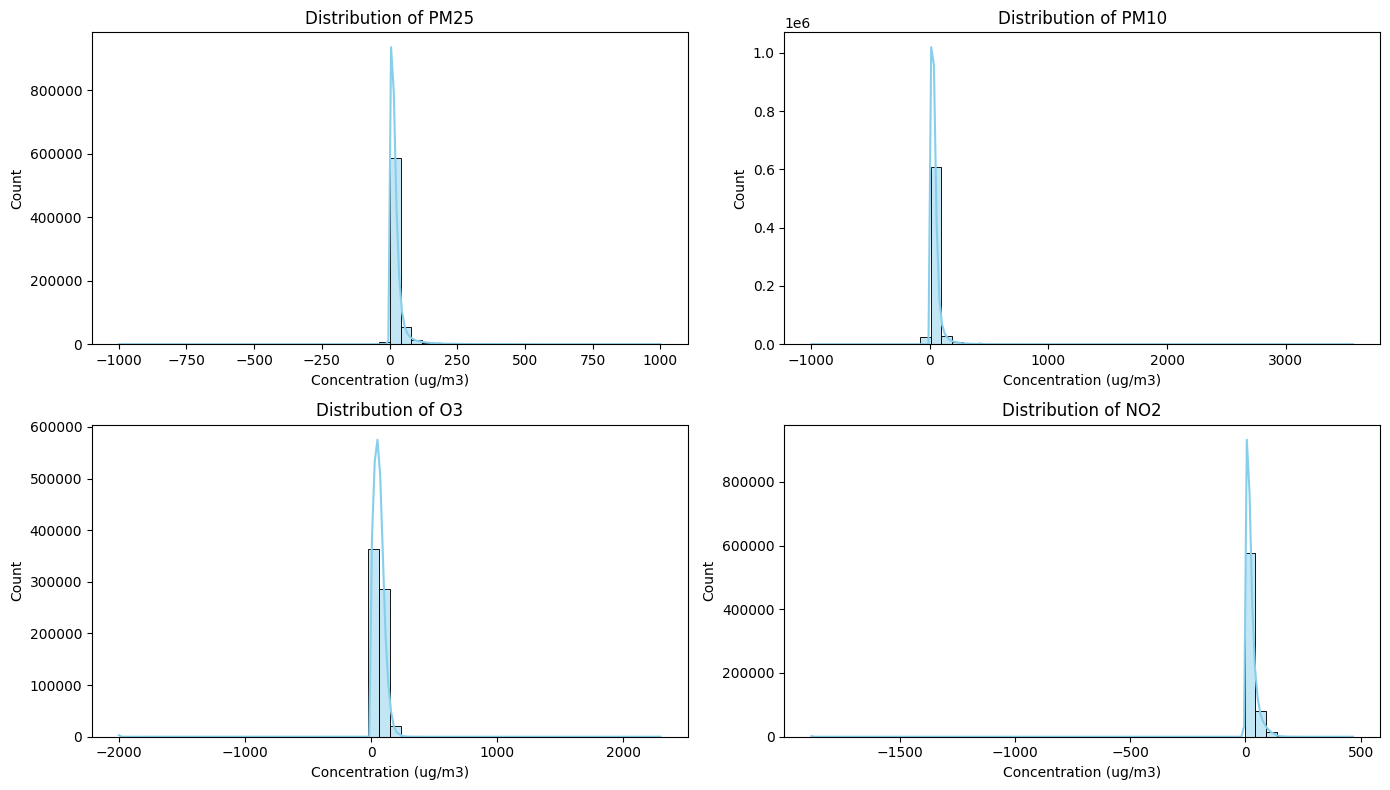

/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_13609/1384784080.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="source", y="pm25", data=df_sampled, palette="Set3")


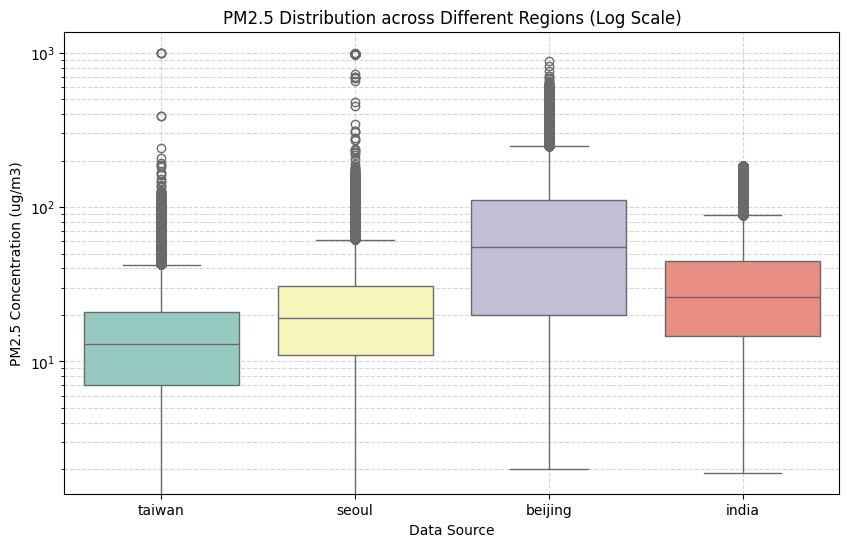

In [23]:
# ── EDA 1: 資料分佈分析 ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取資料
df_proc = pd.read_csv("unified_air_quality_clean.csv")
df_proc["datetime"] = pd.to_datetime(df_proc["datetime"])

# 1. 輸出基本描述統計
print("=== 數值特徵描述統計 ===")
cols_to_analyze = ["pm25", "pm10", "o3", "no2", "latitude", "longitude"]
display(df_proc[cols_to_analyze].describe().round(2))

# 為了繪圖效能，隨機抽樣 10% 的數據進行視覺化
df_sampled = df_proc.sample(frac=0.1, random_state=42)

# 2. 繪製 4 種污染物的分佈直方圖
plt.figure(figsize=(14, 8))
for i, col in enumerate(["pm25", "pm10", "o3", "no2"], 1):
    plt.subplot(2, 2, i)
    # 使用 log 尺度或限制 x 軸範圍，以便更清楚地觀察大部分數據的分佈
    sns.histplot(df_sampled[col], bins=50, kde=True, color="skyblue")
    plt.title(f"Distribution of {col.upper()}")
    plt.xlabel("Concentration (ug/m3)")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3. 繪製各資料來源的 PM2.5 盒鬚圖（對比背景基底濃度差異）
plt.figure(figsize=(10, 6))
sns.boxplot(x="source", y="pm25", data=df_sampled, palette="Set3")
plt.yscale("log")  # 使用對數尺度，以應對不同地區極大濃度的對比
plt.title("PM2.5 Distribution across Different Regions (Log Scale)")
plt.xlabel("Data Source")
plt.ylabel("PM2.5 Concentration (ug/m3)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

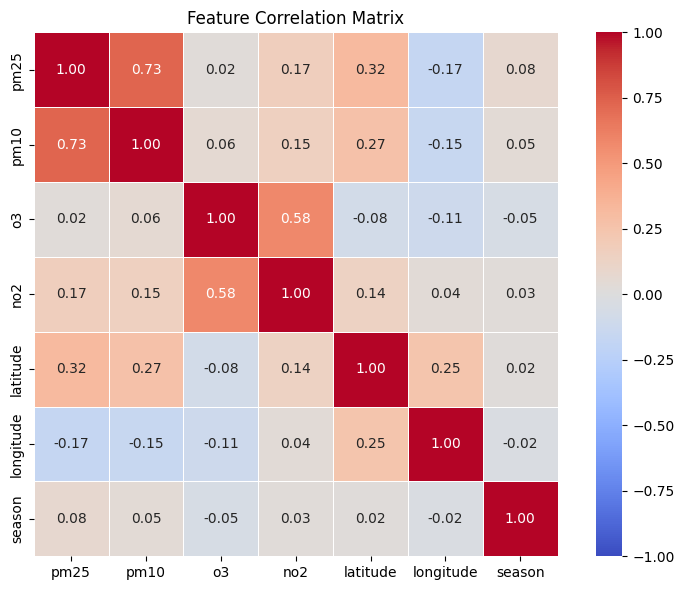

In [24]:
# ── EDA 2: 相關性矩陣分析 ────────────────────────────────────────
# 選擇需要進行相關性分析的特徵
corr_cols = ["pm25", "pm10", "o3", "no2", "latitude", "longitude", "season"]
corr_matrix = df_proc[corr_cols].corr()

# 繪製相關性矩陣熱圖
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,          # 顯示相關係數數值
    cmap="coolwarm",     # 藍紅漸變色調
    fmt=".2f",          # 保留兩位小數
    vmin=-1, vmax=1,     # 範圍限定在 -1 到 1
    linewidths=0.5, 
    square=True
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

代表性測站：Yangming (來源：taiwan)
該站有效連續觀測長度：60564 小時


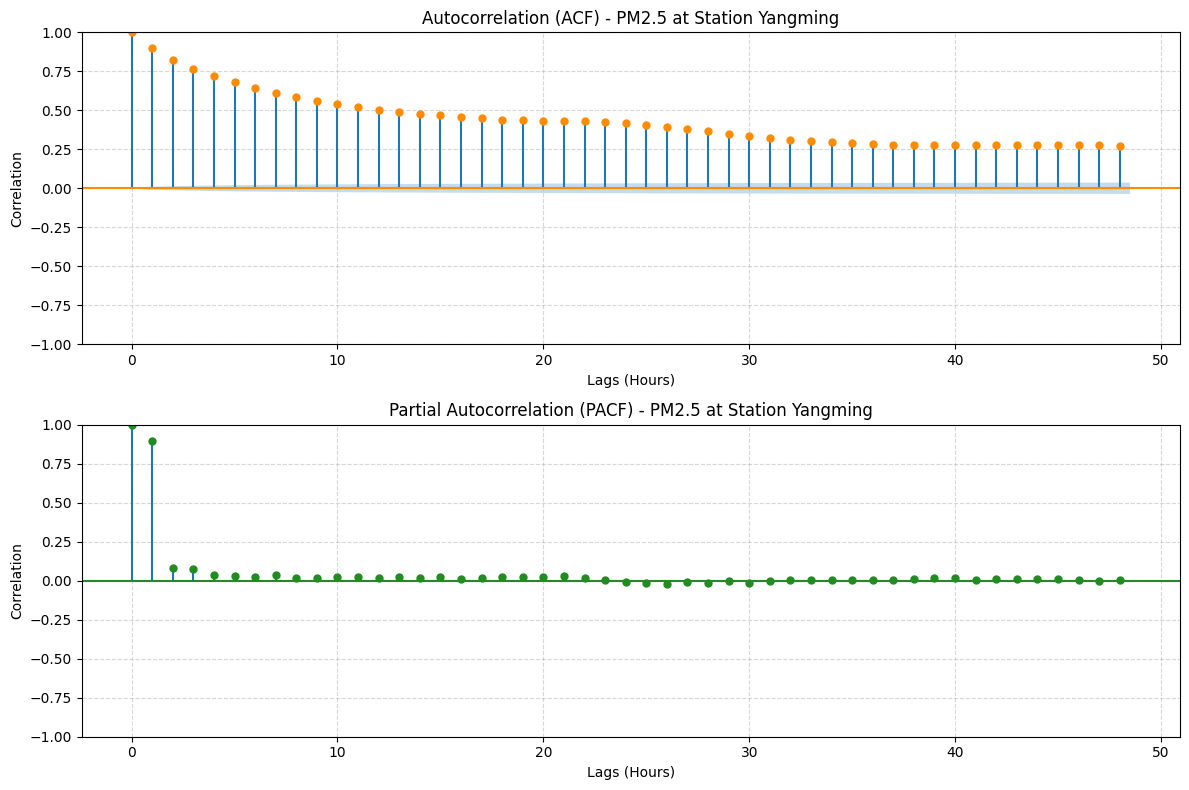

In [25]:
# ── EDA 3: 代表性監測站的時序自相關分析 ───────────────────────────────
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. 自動找出數據量最多（最完整）的測站作為代表
rep_station = df_proc["station"].value_counts().index[0]
rep_source = df_proc[df_proc["station"] == rep_station]["source"].iloc[0]

# 2. 提取該測站的數據，並依時間嚴格排序
df_rep = df_proc[df_proc["station"] == rep_station].sort_values("datetime").reset_index(drop=True)

print(f"代表性測站：{rep_station} (來源：{rep_source})")
print(f"該站有效連續觀測長度：{len(df_rep)} 小時")

# 3. 繪製 ACF 與 PACF (觀測 48 個 Lag 滯後，即 2 天)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 自相關圖 (ACF)：展示當前濃度與過去不同時間點的整體關聯性
plot_acf(df_rep["pm25"].dropna(), lags=48, ax=axes[0], color="darkorange")
axes[0].set_title(f"Autocorrelation (ACF) - PM2.5 at Station {rep_station}")
axes[0].set_xlabel("Lags (Hours)")
axes[0].set_ylabel("Correlation")
axes[0].grid(True, ls="--", alpha=0.5)

# 偏自相關圖 (PACF)：剔除中間時間點的影響，純粹展示特定滯後點的直接關聯
plot_pacf(df_rep["pm25"].dropna(), lags=48, ax=axes[1], color="forestgreen", method="ywm")
axes[1].set_title(f"Partial Autocorrelation (PACF) - PM2.5 at Station {rep_station}")
axes[1].set_xlabel("Lags (Hours)")
axes[1].set_ylabel("Correlation")
axes[1].grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [26]:
# ── 診斷分析：找出並列印無效值（異常值） ───────────────────────────────
import pandas as pd
import numpy as np

# 讀取合併後的資料集
df_diagnostic = pd.read_csv("unified_air_quality_clean.csv")

pollutants = ["pm25", "pm10", "o3", "no2"]

print("==================================================")
print("             1. 負值無效值診斷統計 (小於 0)")
print("==================================================")

for col in pollutants:
    # 找出小於 0 的異常數據
    invalid_neg = df_diagnostic[df_diagnostic[col] < 0]
    num_neg = len(invalid_neg)
    
    print(f"【{col.upper()}】")
    print(f"  -> 負值總筆數: {num_neg:,} 筆 (佔總體 {num_neg / len(df_diagnostic) * 100:.4f}%)")
    
    if num_neg > 0:
        # 1. 印出最常出現的負值代碼（通常是 -999 或 -99.9 等）
        print("  -> 最常見的負值代碼與其出現次數：")
        print(invalid_neg[col].value_counts().head(5).to_string())
        
        # 2. 印出這些負值主要來自哪一個國家/地區
        print("  -> 負值來源地區分布：")
        print(invalid_neg["source"].value_counts().to_string())
    else:
        print("  -> 未偵測到負值無效值。")
    print("-" * 50)


print("\n==================================================")
print("             2. 極端高值異常值診斷統計")
print("==================================================")

# 定義各指標在學術與實務上極端罕見的物理高值閾值
high_thresholds = {
    "pm25": 1000.0,    # PM2.5 > 1000 ug/m3
    "pm10": 2000.0,    # PM10 > 2000 ug/m3
    "o3": 1000.0,      # O3 > 1000 ug/m3 (極高臭氧)
    "no2": 1000.0      # NO2 > 1000 ug/m3
}

for col, thresh in high_thresholds.items():
    invalid_high = df_diagnostic[df_diagnostic[col] > thresh]
    num_high = len(invalid_high)
    
    print(f"【{col.upper()}】大於 {thresh} ug/m3")
    print(f"  -> 極端高值總筆數: {num_high:,} 筆")
    
    if num_high > 0:
        print(f"  -> 這些極端高值的來源地區分布與最大值：")
        stats = invalid_high.groupby("source")[col].agg(["count", "min", "max"])
        print(stats.to_string())
    else:
        print(f"  -> 未偵測到大於 {thresh} ug/m3 的極端高值。")
    print("-" * 50)

/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_13609/14625763.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_diagnostic = pd.read_csv("unified_air_quality_clean.csv")


             1. 負值無效值診斷統計 (小於 0)
【PM25】
  -> 負值總筆數: 4,001 筆 (佔總體 0.0594%)
  -> 最常見的負值代碼與其出現次數：
pm25
-1.0      3973
-999.0      28
  -> 負值來源地區分布：
source
seoul     3973
taiwan      28
--------------------------------------------------
【PM10】
  -> 負值總筆數: 3,988 筆 (佔總體 0.0592%)
  -> 最常見的負值代碼與其出現次數：
pm10
-1.0      3962
-999.0      26
  -> 負值來源地區分布：
source
seoul     3962
taiwan      26
--------------------------------------------------
【O3】
  -> 負值總筆數: 4,377 筆 (佔總體 0.0650%)
  -> 最常見的負值代碼與其出現次數：
o3
-2000.0    4059
-0.2         98
-0.4         72
-0.6         34
-1.2         22
  -> 負值來源地區分布：
source
seoul     4059
taiwan     318
--------------------------------------------------
【NO2】
  -> 負值總筆數: 4,627 筆 (佔總體 0.0687%)
  -> 最常見的負值代碼與其出現次數：
no2
-1882.0000    3834
-0.1882        205
-0.3764        153
-0.5646        145
-0.9410        141
  -> 負值來源地區分布：
source
seoul     3834
taiwan     793
--------------------------------------------------

             2. 極端高值異常值診斷統計
【PM25】大於 1000.0 ug/m3
  -> 極端

In [27]:
# ── 直接對最終清洗檔 (unified_air_quality_clean.csv) 進行二次修復並重新輸出 ──
import pandas as pd
import numpy as np

file_path = "unified_air_quality_clean.csv"

# 1. 讀取現有檔案，強制指定 station 為字串，解決 DtypeWarning
df = pd.read_csv(file_path, dtype={"station": str})
print(f"載入原始資料形狀：{df.shape}")

# 2. 定義異常高值物理合理上限（超過此數值即視為感測器故障，轉為 NaN）
high_thresholds = {
    "pm25": 1000.0,    # PM2.5 > 1000 ug/m3
    "pm10": 2000.0,    # PM10 > 2000 ug/m3
    "o3": 800.0,       # O3 > 800 ug/m3
    "no2": 800.0       # NO2 > 800 ug/m3
}

print("\n=== 開始修復物理無效值與極端噪訊 ===")
for col in ["pm25", "pm10", "o3", "no2"]:
    # A. 處理負值：只要小於 0 均設為 NaN
    neg_mask = df[col] < 0
    num_neg = neg_mask.sum()
    df.loc[neg_mask, col] = np.nan
    print(f"【{col.upper()}】已將 {num_neg:,} 筆 負值 設為 NaN")
    
    # B. 處理極端高值：超過上限均設為 NaN
    limit = high_thresholds[col]
    high_mask = df[col] > limit
    num_high = high_mask.sum()
    df.loc[high_mask, col] = np.nan
    print(f"【{col.upper()}】已將 {num_high:,} 筆 超出 {limit} ug/m3 的極端高值 設為 NaN")
    print("-" * 50)

# 3. 按測站排序，對新產生的 NaN 進行時間序列前向填補 (ffill)
print("\n=== 重新進行時間序列前向填補 (ffill) ===")
df = df.sort_values(["source", "station", "datetime"])
check_cols = ["pm25", "pm10", "o3", "no2"]
df[check_cols] = df.groupby("station")[check_cols].transform(lambda x: x.ffill())

# 4. 剔除在序列最開頭就缺失、無法被 ffill 遞補的極少數殘餘 NaN
df = df.dropna(subset=check_cols).reset_index(drop=True)

# 5. 【關鍵】因為 PM2.5 數據已被修正，重新計算超標標籤與濃度等級
print("\n=== 依據修復後的數值，重新計算標籤 ===")
df["pm25_exceed"] = (df["pm25"] > 35.4).astype(float)

bins = [float("-inf"), 15.4, 35.4, 54.4, 150.4, 250.4, float("inf")]
labels = [0, 1, 2, 3, 4, 5]
df["pm25_level"] = pd.cut(df["pm25"], bins=bins, labels=labels).astype(int)

# 6. 重新儲存輸出，覆蓋原檔案
df.to_csv(file_path, index=False)
print(f"\n修正完成！已成功更新覆蓋至：{file_path}")
print(f"最終資料形狀：{df.shape}")

載入原始資料形狀：(6731463, 16)

=== 開始修復物理無效值與極端噪訊 ===
【PM25】已將 4,001 筆 負值 設為 NaN
【PM25】已將 1 筆 超出 1000.0 ug/m3 的極端高值 設為 NaN
--------------------------------------------------
【PM10】已將 3,988 筆 負值 設為 NaN
【PM10】已將 94 筆 超出 2000.0 ug/m3 的極端高值 設為 NaN
--------------------------------------------------
【O3】已將 4,377 筆 負值 設為 NaN
【O3】已將 54 筆 超出 800.0 ug/m3 的極端高值 設為 NaN
--------------------------------------------------
【NO2】已將 4,627 筆 負值 設為 NaN
【NO2】已將 5 筆 超出 800.0 ug/m3 的極端高值 設為 NaN
--------------------------------------------------

=== 重新進行時間序列前向填補 (ffill) ===

=== 依據修復後的數值，重新計算標籤 ===

修正完成！已成功更新覆蓋至：unified_air_quality_clean.csv
最終資料形狀：(6731463, 16)


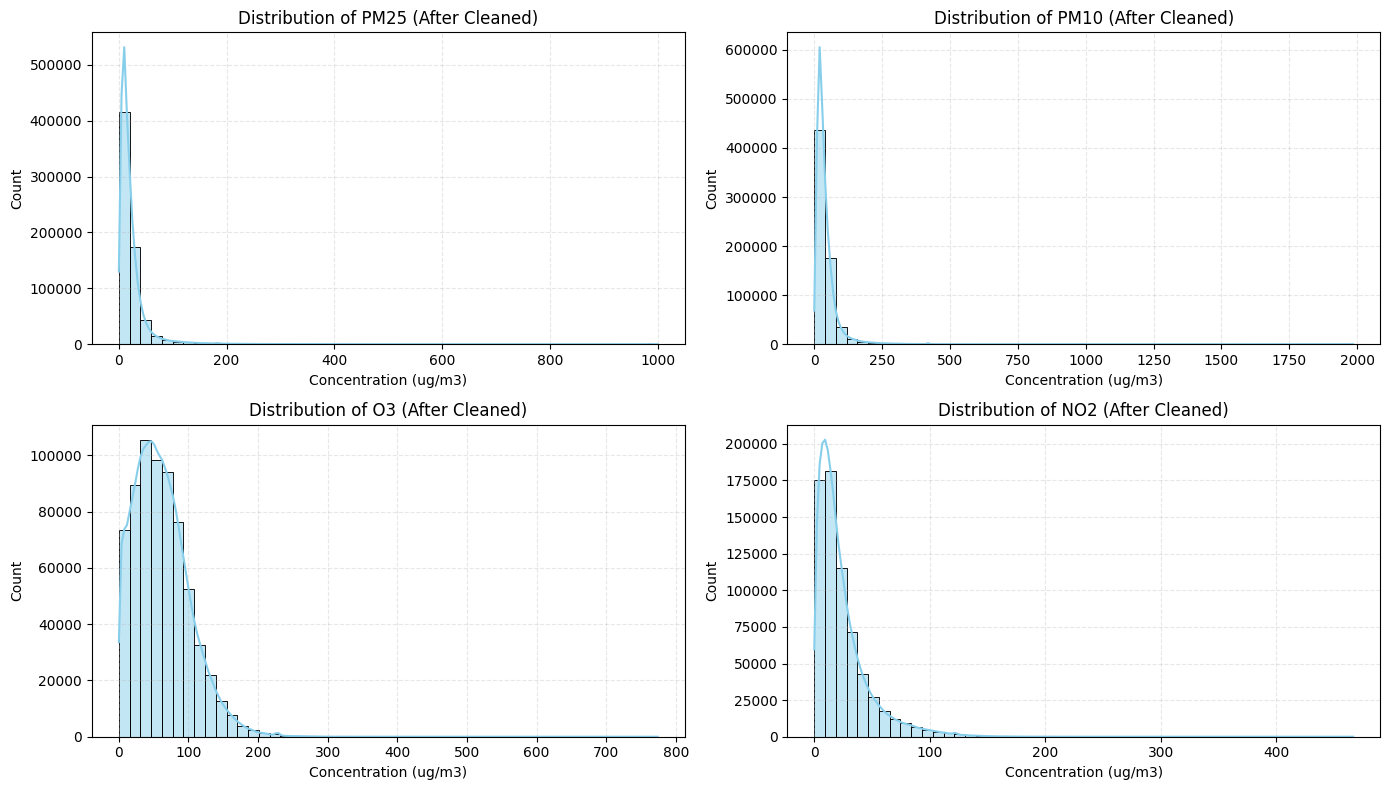

/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_13609/594378238.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="source", y="pm25", data=df_sampled, palette="Set3")


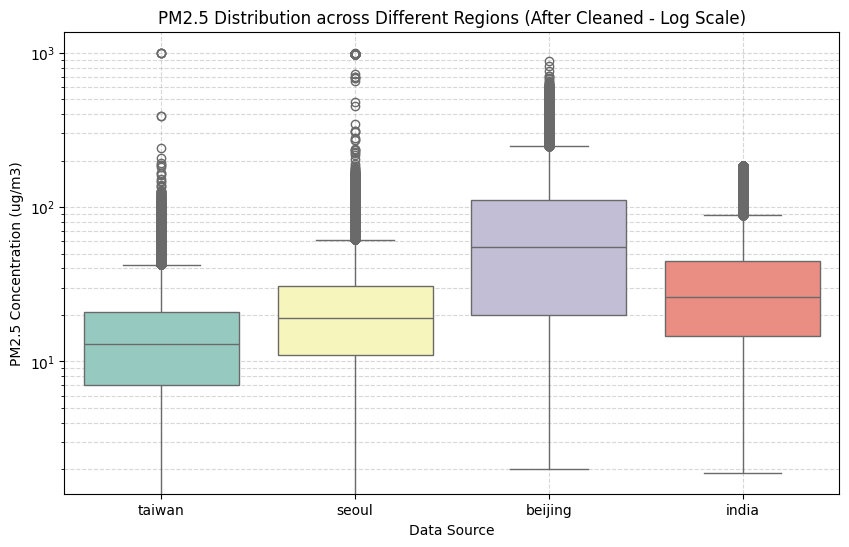

In [28]:
# ── 重新繪製修復後的資料分佈視覺化 ────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 讀取修復後的乾淨資料，強制指定 station 為字串避免警告
df_clean = pd.read_csv("unified_air_quality_clean.csv", dtype={"station": str})

# 為了繪圖效能，隨機抽樣 10% 的數據進行視覺化
df_sampled = df_clean.sample(frac=0.1, random_state=42)

# 2. 重新繪製 4 種污染物的分佈直方圖 (此時 X 軸的負值已全部被清除)
plt.figure(figsize=(14, 8))
for i, col in enumerate(["pm25", "pm10", "o3", "no2"], 1):
    plt.subplot(2, 2, i)
    # 繪製直方圖與核密度估計圖 (KDE)
    sns.histplot(df_sampled[col], bins=50, kde=True, color="skyblue")
    plt.title(f"Distribution of {col.upper()} (After Cleaned)")
    plt.xlabel("Concentration (ug/m3)")
    plt.ylabel("Count")
    plt.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

# 3. 重新繪製各資料來源的 PM2.5 盒鬚圖 (排除極端值干擾後，能更精準觀察各國分布)
plt.figure(figsize=(10, 6))
sns.boxplot(x="source", y="pm25", data=df_sampled, palette="Set3")
plt.yscale("log")  # 使用對數尺度能更清晰對比低濃度到高濃度的跨國中位數分布
plt.title("PM2.5 Distribution across Different Regions (After Cleaned - Log Scale)")
plt.xlabel("Data Source")
plt.ylabel("PM2.5 Concentration (ug/m3)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

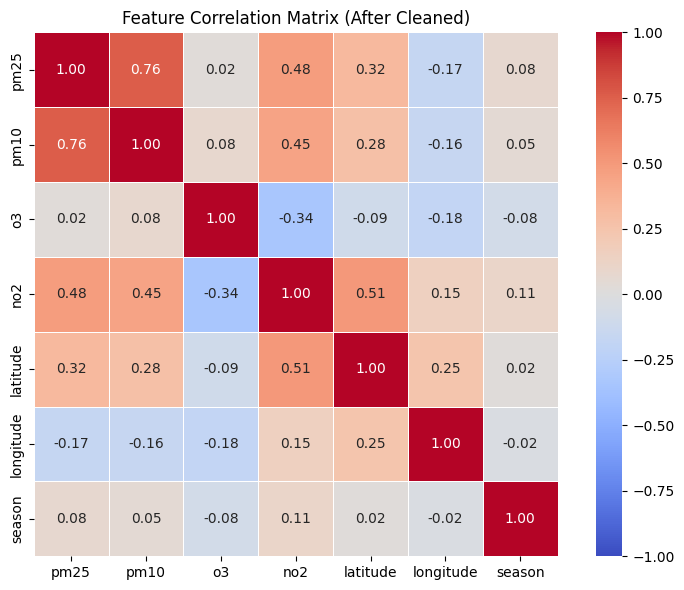

In [29]:
# ── 重新繪製修復後的相關性熱圖 ────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取乾淨資料
df_clean = pd.read_csv("unified_air_quality_clean.csv", dtype={"station": str})

# 選擇特徵欄位
corr_cols = ["pm25", "pm10", "o3", "no2", "latitude", "longitude", "season"]
corr_matrix = df_clean[corr_cols].corr()

# 繪製熱圖
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True,          # 顯示數值
    cmap="coolwarm",     # 漸變色調
    fmt=".2f",          # 保留兩位小數
    vmin=-1, vmax=1,     # 限定範圍
    linewidths=0.5, 
    square=True
)
plt.title("Feature Correlation Matrix (After Cleaned)")
plt.tight_layout()
plt.show()

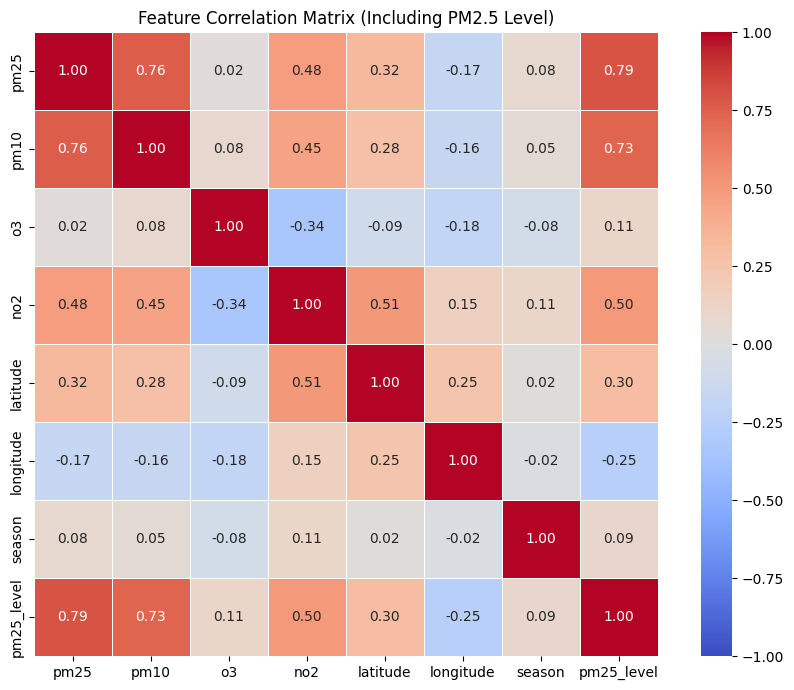

In [31]:
# ── 相關性熱圖 (加入 pm25_level) ────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取乾淨資料
df_clean = pd.read_csv("unified_air_quality_clean.csv", dtype={"station": str})

# 選擇特徵欄位（加入 6 等級標籤 pm25_level）
corr_cols = ["pm25", "pm10", "o3", "no2", "latitude", "longitude", "season", "pm25_level"]
corr_matrix = df_clean[corr_cols].corr()

# 繪製熱圖
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, 
    annot=True,          # 顯示數值
    cmap="coolwarm",     # 漸變色調
    fmt=".2f",          # 保留兩位小數
    vmin=-1, vmax=1,     # 限定範圍
    linewidths=0.5, 
    square=True
)
plt.title("Feature Correlation Matrix (Including PM2.5 Level)")
plt.tight_layout()
plt.show()

代表性測站：Yangming (來源：taiwan)
該站有效連續觀測長度：60564 小時


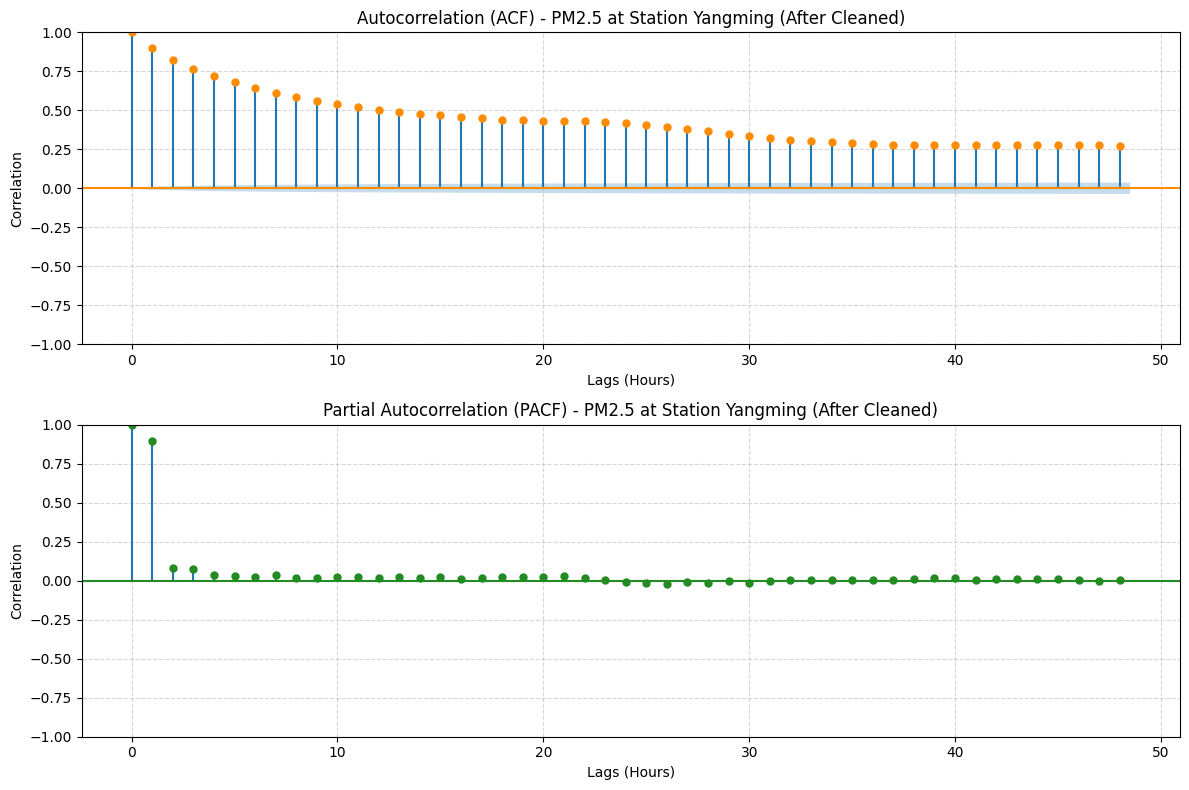

In [30]:
# ── 重新繪製修復後的時序自相關圖 (ACF / PACF) ───────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 讀取乾淨資料
df_clean = pd.read_csv("unified_air_quality_clean.csv", dtype={"station": str})

# 優先選擇 Yangming (陽明) 測站進行自相關分析
if "Yangming" in df_clean["station"].values:
    rep_station = "Yangming"
else:
    rep_station = df_clean["station"].value_counts().index[0]

rep_source = df_clean[df_clean["station"] == rep_station]["source"].iloc[0]

# 提取資料並按時間排序
df_rep = df_clean[df_clean["station"] == rep_station].sort_values("datetime").reset_index(drop=True)

print(f"代表性測站：{rep_station} (來源：{rep_source})")
print(f"該站有效連續觀測長度：{len(df_rep)} 小時")

# 繪圖 (觀測 48 小時)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# A. 自相關圖 (ACF)
plot_acf(df_rep["pm25"].dropna(), lags=48, ax=axes[0], color="darkorange")
axes[0].set_title(f"Autocorrelation (ACF) - PM2.5 at Station {rep_station} (After Cleaned)")
axes[0].set_xlabel("Lags (Hours)")
axes[0].set_ylabel("Correlation")
axes[0].grid(True, ls="--", alpha=0.5)

# B. 偏自相關圖 (PACF)
plot_pacf(df_rep["pm25"].dropna(), lags=48, ax=axes[1], color="forestgreen", method="ywm")
axes[1].set_title(f"Partial Autocorrelation (PACF) - PM2.5 at Station {rep_station} (After Cleaned)")
axes[1].set_xlabel("Lags (Hours)")
axes[1].set_ylabel("Correlation")
axes[1].grid(True, ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

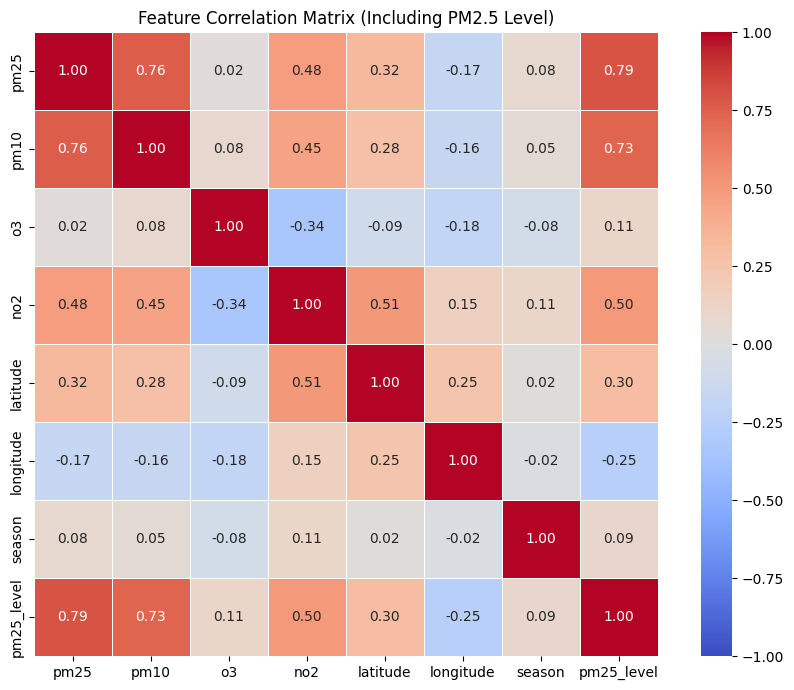

In [32]:
# ── 相關性熱圖 (加入 pm25_level) ────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 讀取乾淨資料
df_clean = pd.read_csv("unified_air_quality_clean.csv", dtype={"station": str})

# 選擇特徵欄位（加入 6 等級標籤 pm25_level）
corr_cols = ["pm25", "pm10", "o3", "no2", "latitude", "longitude", "season", "pm25_level"]
corr_matrix = df_clean[corr_cols].corr()

# 繪製熱圖
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, 
    annot=True,          # 顯示數值
    cmap="coolwarm",     # 漸變色調
    fmt=".2f",          # 保留兩位小數
    vmin=-1, vmax=1,     # 限定範圍
    linewidths=0.5, 
    square=True
)
plt.title("Feature Correlation Matrix (Including PM2.5 Level)")
plt.tight_layout()
plt.show()

In [33]:
# ── 驗證集與測試集的 6 等級資料分佈分析 ────────────────────────────────────────
import pandas as pd
import numpy as np

# 1. 透過經緯度，自動在 Pandas 中篩選出台灣測站的名稱
is_taiwan = (df_clean["latitude"] > 21.0) & (df_clean["latitude"] < 26.0) & \
            (df_clean["longitude"] > 119.0) & (df_clean["longitude"] < 123.0)
taiwan_stations = df_clean[is_taiwan]["station"].unique()

# 2. 進行測站獨立的時序切片
train_list, val_list, test_list = [], [], []

print("正在進行測站獨立時序切分...")
for station, grp in df_clean.groupby("station"):
    grp = grp.sort_values("datetime")
    length = len(grp)
    
    if station in taiwan_stations:
        # 台灣測站：70% Train / 20% Test / 10% Val
        split1 = int(length * 0.70)
        split2 = int(length * 0.90)
        train_list.append(grp.iloc[:split1])
        test_list.append(grp.iloc[split1:split2])
        val_list.append(grp.iloc[split2:])
    else:
        # 其他測站：80% Train / 20% Test
        split1 = int(length * 0.80)
        train_list.append(grp.iloc[:split1])
        test_list.append(grp.iloc[split1:])

# 合併各區塊
df_train = pd.concat(train_list, ignore_index=True)
df_val = pd.concat(val_list, ignore_index=True)
df_test = pd.concat(test_list, ignore_index=True)

# 3. 類別名稱對照
level_names = {
    0: "良好 (Good)",
    1: "普通 (Moderate)",
    2: "對敏感族群不健康 (USG)",
    3: "對所有族群不健康 (Unhealthy)",
    4: "非常不健康 (Very Unhealthy)",
    5: "危害 (Hazardous)"
}

# 4. 分析與印出結果
def analyze_distribution(df, dataset_name):
    total = len(df)
    dist = df["pm25_level"].value_counts().sort_index()
    
    print(f"\n==================================================")
    print(f" 📊 {dataset_name} 資料分布分析 (總筆數: {total:,} 筆)")
    print(f"==================================================")
    
    report = []
    for lvl in range(6):
        count = dist.get(lvl, 0)
        pct = (count / total * 100)
        report.append({
            "AQI 等級": level_names[lvl],
            "筆數 (Counts)": f"{count:,}",
            "佔比 (%)": f"{pct:.4f}%"
        })
    display(pd.DataFrame(report))

analyze_distribution(df_val, "驗證集 (Validation Set - 台灣最後10%)")
analyze_distribution(df_test, "測試集 (Test Set - 各國最新20%)")

正在進行測站獨立時序切分...

 📊 驗證集 (Validation Set - 台灣最後10%) 資料分布分析 (總筆數: 470,093 筆)


,AQI 等級,筆數 (Counts),佔比 (%)
0,良好 (Good),"292,906",62.3081%
1,普通 (Moderate),"155,066",32.9862%
2,對敏感族群不健康 (USG),"20,178",4.2923%
3,對所有族群不健康 (Unhealthy),"1,932",0.4110%
4,非常不健康 (Very Unhealthy),11,0.0023%
5,危害 (Hazardous),0,0.0000%



 📊 測試集 (Test Set - 各國最新20%) 資料分布分析 (總筆數: 1,346,305 筆)


,AQI 等級,筆數 (Counts),佔比 (%)
0,良好 (Good),"755,770",56.1366%
1,普通 (Moderate),"434,836",32.2985%
2,對敏感族群不健康 (USG),"84,528",6.2785%
3,對所有族群不健康 (Unhealthy),"57,540",4.2739%
4,非常不健康 (Very Unhealthy),"9,318",0.6921%
5,危害 (Hazardous),"4,313",0.3204%


In [14]:
# ── Cell 7：重新計算特徵工程（25 個特徵） ───────────────────────────────
import numpy as np
import pandas as pd
import pickle
from sklearn.preprocessing import LabelEncoder

# 1. 讀取修復後的乾淨檔案，強制指定 station 為字串
df_proc = pd.read_csv("unified_air_quality_clean.csv", dtype={"station": str})
df_proc["datetime"] = pd.to_datetime(df_proc["datetime"])

# 2. 嚴格按測站與時間排序
df_proc = df_proc.sort_values(["source", "station", "datetime"]).reset_index(drop=True)

# 3. 重新計算 4 種污染物無噪訊干擾的 3, 6, 12 小時歷史移動平均
pollutants_to_roll = ["pm25", "pm10", "o3", "no2"]
roll_windows = [3, 6, 12]

print("系統訊息：正在為各監測站重新計算 3, 6, 12 小時移動平均...")
for col in pollutants_to_roll:
    for w in roll_windows:
        col_name = f"{col}_roll_{w}"
        # 依據測站進行分組 rolling
        df_proc[col_name] = df_proc.groupby("station")[col].transform(
            lambda x: x.rolling(window=w, min_periods=1).mean()
        )

# 4. 計算時間週期特徵
df_proc["hour_sin"] = np.sin(2 * np.pi * df_proc["hour"] / 24)
df_proc["hour_cos"] = np.cos(2 * np.pi * df_proc["hour"] / 24)
df_proc["month_sin"] = np.sin(2 * np.pi * (df_proc["month"] - 1) / 12)
df_proc["month_cos"] = np.cos(2 * np.pi * (df_proc["month"] - 1) / 12)

# 5. 地區來源標籤編碼
le = LabelEncoder()
df_proc["source_enc"] = le.fit_transform(df_proc["source"])
print("source mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# 6. 定義 25 個輸入特徵（已完全移除 wind_speed）
FEAT_COLS = [
    "pm25", "pm10", "o3", "no2",
    "pm25_roll_3", "pm25_roll_6", "pm25_roll_12",
    "pm10_roll_3", "pm10_roll_6", "pm10_roll_12",
    "o3_roll_3", "o3_roll_6", "o3_roll_12",
    "no2_roll_3", "no2_roll_6", "no2_roll_12",
    "latitude", "longitude",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "day", "season", "source_enc"
]

print(f"\n特徵數：{len(FEAT_COLS)}")
print(f"特徵欄位清單：{FEAT_COLS}")

# 儲存 LabelEncoder 供後續推論使用
with open("encoder.pkl", "wb") as f:
    pickle.dump({"le": le}, f)

df_proc.to_csv("unified_air_quality_processed.csv", index=False)
print(f"\nunified_air_quality_processed.csv 重新儲存成功，shape={df_proc.shape}")


系統訊息：正在為各監測站重新計算 3, 6, 12 小時移動平均...
source mapping: {'beijing': np.int64(0), 'india': np.int64(1), 'seoul': np.int64(2), 'taiwan': np.int64(3)}

特徵數：25
特徵欄位清單：['pm25', 'pm10', 'o3', 'no2', 'pm25_roll_3', 'pm25_roll_6', 'pm25_roll_12', 'pm10_roll_3', 'pm10_roll_6', 'pm10_roll_12', 'o3_roll_3', 'o3_roll_6', 'o3_roll_12', 'no2_roll_3', 'no2_roll_6', 'no2_roll_12', 'latitude', 'longitude', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'day', 'season', 'source_enc']

unified_air_quality_processed.csv 重新儲存成功，shape=(6731463, 33)


In [15]:
# ── Cell 8：滑動視窗切片並輸出為 windows.npz ──────────────────────────────────
WINDOW = 24
HORIZONS = [1, 3, 6]

TARGET_REG = ["pm25", "pm10", "o3", "no2"]
TARGET_CLS = "pm25_exceed"
TARGET_LEVEL = "pm25_level"

all_X, all_y_reg, all_y_cls, all_y_level = [], [], [], []

# 按測站與時間排序，確保視窗連續性
df_sorted = df_proc.sort_values(["station", "datetime"]).reset_index(drop=True)
max_h = max(HORIZONS)

print("系統訊息：正在進行滑動視窗時序切片...")
for station, grp in df_sorted.groupby("station", sort=False):
    grp = grp.reset_index(drop=True)
    n = len(grp)
    if n < WINDOW + max_h:
        continue
    
    # 轉換為 numpy array 以加速切片過程
    X_v = grp[FEAT_COLS].values.astype(np.float32)
    yr_v = grp[TARGET_REG].values.astype(np.float32)
    yc_v = grp[TARGET_CLS].values.astype(np.float32)
    yl_v = grp[TARGET_LEVEL].values.astype(np.float32)
    
    for i in range(WINDOW, n - max_h + 1):
        idx = [i + h - 1 for h in HORIZONS]
        all_X.append(X_v[i - WINDOW:i])
        all_y_reg.append(yr_v[idx])     # 預測未來 1, 3, 6 小時的濃度
        all_y_cls.append(yc_v[idx])     # 預測未來 1, 3, 6 小時的超標情況
        all_y_level.append(yl_v[idx])   # 預測未來 1, 3, 6 小時的等級分類

X_arr = np.array(all_X, dtype=np.float32)
y_reg_arr = np.array(all_y_reg, dtype=np.float32)
y_cls_arr = np.array(all_y_cls, dtype=np.float32)
y_level_arr = np.array(all_y_level, dtype=np.float32)

print("\n=== 滑動視窗打包成功 ===")
print(f"X       : {X_arr.shape} (samples, window=24, features=25)")
print(f"y_reg   : {y_reg_arr.shape} (samples, horizons=3, pollutants=4)")
print(f"y_cls   : {y_cls_arr.shape} (samples, horizons=3)")
print(f"y_level : {y_level_arr.shape} (samples, horizons=3)")

# 儲存為壓縮檔
np.savez_compressed("windows.npz", 
                    X=X_arr, y_reg=y_reg_arr, y_cls=y_cls_arr, y_level=y_level_arr)
print("\nwindows.npz 已重新壓縮並輸出成功！")

系統訊息：正在進行滑動視窗時序切片...

=== 滑動視窗打包成功 ===
X       : (6726491, 24, 25) (samples, window=24, features=25)
y_reg   : (6726491, 3, 4) (samples, horizons=3, pollutants=4)
y_cls   : (6726491, 3) (samples, horizons=3)
y_level : (6726491, 3) (samples, horizons=3)

windows.npz 已重新壓縮並輸出成功！


In [34]:
# ── 方法一：在統一清洗檔上分析時間橫跨 ────────────────────────────────────────
import pandas as pd

# 載入修復後的乾淨檔案
df_clean = pd.read_csv("unified_air_quality_clean.csv")
df_clean["datetime"] = pd.to_datetime(df_clean["datetime"])

print("==================================================")
print("             各國資料集時間橫跨分析 (Cleaned)")
print("==================================================\n")

# 按地區分組計算時間跨度
for source_name, grp in df_clean.groupby("source"):
    start_time = grp["datetime"].min()
    end_time = grp["datetime"].max()
    duration = end_time - start_time
    
    print(f"【{source_name.upper()}】")
    print(f"  -> 起始時間: {start_time}")
    print(f"  -> 結束時間: {end_time}")
    print(f"  -> 時間橫跨: {duration.days:,} 天 (約 {duration.days / 365:.2f} 年)")
    print("-" * 50)

/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_13609/3506883896.py:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clean = pd.read_csv("unified_air_quality_clean.csv")


             各國資料集時間橫跨分析 (Cleaned)

【BEIJING】
  -> 起始時間: 2013-03-01 00:00:00
  -> 結束時間: 2017-02-28 23:00:00
  -> 時間橫跨: 1,460 天 (約 4.00 年)
--------------------------------------------------
【INDIA】
  -> 起始時間: 2022-08-05 00:00:00
  -> 結束時間: 2025-11-26 23:00:00
  -> 時間橫跨: 1,209 天 (約 3.31 年)
--------------------------------------------------
【SEOUL】
  -> 起始時間: 2017-01-01 00:00:00
  -> 結束時間: 2019-12-31 23:00:00
  -> 時間橫跨: 1,094 天 (約 3.00 年)
--------------------------------------------------
【TAIWAN】
  -> 起始時間: 2018-03-26 15:00:00
  -> 結束時間: 2024-08-31 23:00:00
  -> 時間橫跨: 2,350 天 (約 6.44 年)
--------------------------------------------------


In [37]:
import pandas as pd
import numpy as np

# ── 讀取 jp/ 內的三個檔案 ────────────────────────────────────────
df_jp_raw  = pd.read_csv("jp/air_quality_historical.csv")
df_jp_city = pd.read_csv("jp/city_info.csv")  # Tokyo: lat=35.6895, lon=139.69171

# ── 前 5 筆檢視 ────────────────────────────────────────
print("=== air_quality_historical.csv 前 5 筆（原始） ===")
display(df_jp_raw.head())

print(f"\n形狀：{df_jp_raw.shape}")
print(f"欄位：{list(df_jp_raw.columns)}")
print(f"\n資料型態：\n{df_jp_raw.dtypes}")

print("\n=== 缺失值統計 ===")
missing_jp = df_jp_raw.isnull().sum()
pct_jp = (missing_jp / len(df_jp_raw) * 100).round(2)
display(pd.DataFrame({"缺失筆數": missing_jp, "缺失率(%)": pct_jp}))

# ── 對齊 Unified Schema ────────────────────────────────────────
def season_from_month(m):
    if m in [3, 4, 5]:   return 0  # 春
    if m in [6, 7, 8]:   return 1  # 夏
    if m in [9, 10, 11]: return 2  # 秋
    return 3                        # 冬

# 城市資訊（Tokyo）
TOKYO_LAT = df_jp_city.loc[0, "latitude"]
TOKYO_LON = df_jp_city.loc[0, "longitude"]
TOKYO_NAME = df_jp_city.loc[0, "city_name"]  # "Tokyo"

df_j = df_jp_raw.copy()

# 時間欄位（日資料，hour 補 0）
df_j["datetime"] = pd.to_datetime(df_j["date"])
df_j["year"]     = df_j["datetime"].dt.year
df_j["month"]    = df_j["datetime"].dt.month
df_j["day"]      = df_j["datetime"].dt.day
df_j["hour"]     = 0
df_j["season"]   = df_j["month"].apply(season_from_month)

# 空間與來源
df_j["station"]   = TOKYO_NAME
df_j["latitude"]  = TOKYO_LAT
df_j["longitude"] = TOKYO_LON
df_j["source"]    = "japan"

# 污染物欄位（單位 µg/m³，與 UNIFIED_COLS 一致，直接使用）
df_j["pm25_exceed"] = (df_j["pm2_5"] > 35.4).astype(float)

# 此資料集無氣象欄位，補 NaN
df_j["temperature"] = np.nan
df_j["humidity"]    = np.nan
df_j["wind_speed"]  = np.nan
df_j["wind_dir"]    = np.nan

# 欄位重命名
df_japan_std = df_j.rename(columns={
    "pm2_5":            "pm25",
    "ozone":            "o3",
    "nitrogen_dioxide": "no2",
})[["datetime", "year", "month", "day", "hour", "season",
    "station", "latitude", "longitude", "source",
    "pm25", "pm10", "o3", "no2",
    "temperature", "humidity", "wind_speed", "wind_dir",
    "pm25_exceed"]]

print("\n=== Japan (Tokyo) 對齊 Unified Schema 後 ===")
print(f"形狀：{df_japan_std.shape}")
print(f"pm25 範圍：{df_japan_std['pm25'].min():.1f} ~ {df_japan_std['pm25'].max():.1f} µg/m³")
print(f"超標率：{df_japan_std['pm25_exceed'].mean()*100:.1f}%")
print(f"\n⚠ 注意：此資料集為日資料（hour=0），其餘資料集為小時資料")
display(df_japan_std.head())


=== air_quality_historical.csv 前 5 筆（原始） ===


,date,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aerosol_optical_depth,dust,uv_index,us_aqi,european_aqi
0,2022-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-08-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-08-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-08-04,15.933333,10.246667,182.00,77.613333,8.820000,29.266667,0.274000,0.000000,0.810000,NaN,NaN
4,2022-08-05,15.150000,9.904167,164.75,56.550000,8.316667,37.125000,0.401667,0.041667,0.985417,37.866667,32.0



形狀：(1298, 12)
欄位：['date', 'pm10', 'pm2_5', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aerosol_optical_depth', 'dust', 'uv_index', 'us_aqi', 'european_aqi']

資料型態：
date                      object
pm10                     float64
pm2_5                    float64
carbon_monoxide          float64
nitrogen_dioxide         float64
sulphur_dioxide          float64
ozone                    float64
aerosol_optical_depth    float64
dust                     float64
uv_index                 float64
us_aqi                   float64
european_aqi             float64
dtype: object

=== 缺失值統計 ===


,缺失筆數,缺失率(%)
date,0,0.00
pm10,3,0.23
pm2_5,3,0.23
carbon_monoxide,3,0.23
nitrogen_dioxide,3,0.23
sulphur_dioxide,3,0.23
ozone,3,0.23
aerosol_optical_depth,3,0.23
dust,3,0.23
uv_index,3,0.23



=== Japan (Tokyo) 對齊 Unified Schema 後 ===
形狀：(1298, 19)
pm25 範圍：0.7 ~ 87.0 µg/m³
超標率：20.5%

⚠ 注意：此資料集為日資料（hour=0），其餘資料集為小時資料


,datetime,year,month,day,hour,season,station,latitude,longitude,source,pm25,pm10,o3,no2,temperature,humidity,wind_speed,wind_dir,pm25_exceed
0,2022-08-01,2022,8,1,0,1,Tokyo,35.6895,139.69171,japan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2022-08-02,2022,8,2,0,1,Tokyo,35.6895,139.69171,japan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2022-08-03,2022,8,3,0,1,Tokyo,35.6895,139.69171,japan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,2022-08-04,2022,8,4,0,1,Tokyo,35.6895,139.69171,japan,10.246667,15.933333,29.266667,77.613333,NaN,NaN,NaN,NaN,0.0
4,2022-08-05,2022,8,5,0,1,Tokyo,35.6895,139.69171,japan,9.904167,15.150000,37.125000,56.550000,NaN,NaN,NaN,NaN,0.0


In [42]:
# ── Japan 獨立滑動視窗打包（驗證用） ─────────────────────────────
import numpy as np

WINDOW   = 24          # 過去 24 天（日資料）
HORIZONS = [1, 3, 6]   # 預測未來 1, 3, 6 天後

TARGET_REG   = ["pm25", "pm10", "o3", "no2"]
TARGET_CLS   = "pm25_exceed"
TARGET_LEVEL = "pm25_level"

FEAT_COLS = [
    "pm25", "pm10", "o3", "no2",
    "pm25_roll_3", "pm25_roll_6", "pm25_roll_12",
    "pm10_roll_3", "pm10_roll_6", "pm10_roll_12",
    "o3_roll_3",   "o3_roll_6",   "o3_roll_12",
    "no2_roll_3",  "no2_roll_6",  "no2_roll_12",
    "latitude", "longitude",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "day", "season", "source_enc"
]

all_X, all_y_reg, all_y_cls, all_y_level = [], [], [], []

df_sorted = df_j2.sort_values(["station", "datetime"]).reset_index(drop=True)
max_h = max(HORIZONS)

for station, grp in df_sorted.groupby("station", sort=False):
    grp = grp.reset_index(drop=True)
    n = len(grp)
    if n < WINDOW + max_h:
        print(f"⚠ {station} 筆數不足（{n}），跳過")
        continue

    X_v  = grp[FEAT_COLS].values.astype(np.float32)
    yr_v = grp[TARGET_REG].values.astype(np.float32)
    yc_v = grp[TARGET_CLS].values.astype(np.float32)
    yl_v = grp[TARGET_LEVEL].values.astype(np.float32)

    for i in range(WINDOW, n - max_h + 1):
        idx = [i + h - 1 for h in HORIZONS]
        all_X.append(X_v[i - WINDOW:i])
        all_y_reg.append(yr_v[idx])
        all_y_cls.append(yc_v[idx])
        all_y_level.append(yl_v[idx])

X_arr       = np.array(all_X,       dtype=np.float32)
y_reg_arr   = np.array(all_y_reg,   dtype=np.float32)
y_cls_arr   = np.array(all_y_cls,   dtype=np.float32)
y_level_arr = np.array(all_y_level, dtype=np.float32)

print("=== Japan 驗證集滑動視窗打包完成 ===")
print(f"X       : {X_arr.shape}  (samples, window=24天, features=25)")
print(f"y_reg   : {y_reg_arr.shape}  (samples, horizons=3, pollutants=4)")
print(f"y_cls   : {y_cls_arr.shape}  (samples, horizons=3)")
print(f"y_level : {y_level_arr.shape}  (samples, horizons=3)")

np.savez_compressed("windows_japan.npz",
                    X=X_arr, y_reg=y_reg_arr, y_cls=y_cls_arr, y_level=y_level_arr)
print("\nwindows_japan.npz 已儲存（獨立驗證集，不混入訓練資料）")


=== Japan 驗證集滑動視窗打包完成 ===
X       : (1266, 24, 25)  (samples, window=24天, features=25)
y_reg   : (1266, 3, 4)  (samples, horizons=3, pollutants=4)
y_cls   : (1266, 3)  (samples, horizons=3)
y_level : (1266, 3)  (samples, horizons=3)

windows_japan.npz 已儲存（獨立驗證集，不混入訓練資料）


=== 各資料集 pm25_level 分布 ===



,總筆數,Lv0(%),Lv1(%),Lv2(%),Lv3(%),Lv4(%),Lv5(%)
來源,,,,,,,
beijing,420746,19.51,17.76,12.31,35.15,10.73,4.56
india,842160,26.94,38.14,17.57,16.24,1.11,0.00
taiwan,4821046,59.92,33.27,5.68,1.12,0.00,0.00
seoul,647511,38.14,42.92,12.15,6.52,0.08,0.18
japan,1295,23.94,55.52,17.07,3.47,0.00,0.00


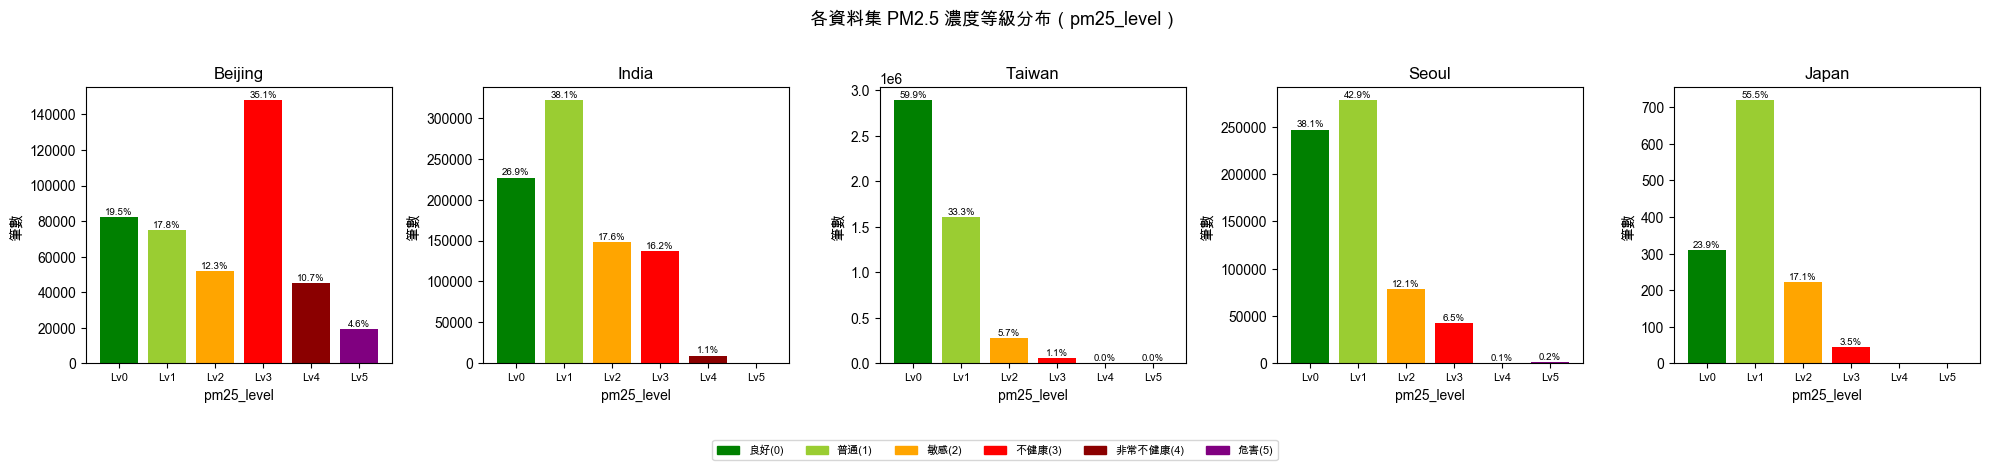

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "Arial Unicode MS"

# ── 讀取已處理好的四來源資料 ──────────────────────────────────────
df_clean = pd.read_csv("unified_air_quality_clean.csv", dtype={"station": str})

# ── 為 Japan 補上 source 欄位後合併（只需 source + pm25_level） ──
df_jp_label = df_j2[["source", "pm25_level"]].copy()
df_all = pd.concat([df_clean[["source", "pm25_level"]], df_jp_label], ignore_index=True)

# ── 設定 ─────────────────────────────────────────────────────────
bins        = [float("-inf"), 15.4, 35.4, 54.4, 150.4, 250.4, float("inf")]
label_names = ["良好(0)", "普通(1)", "敏感(2)", "不健康(3)", "非常不健康(4)", "危害(5)"]
colors      = ["green", "yellowgreen", "orange", "red", "darkred", "purple"]
sources     = ["beijing", "india", "taiwan", "seoul", "japan"]

# ── 數字表格 ──────────────────────────────────────────────────────
print("=== 各資料集 pm25_level 分布 ===\n")
summary_rows = []
for src in sources:
    sub = df_all[df_all["source"] == src]["pm25_level"]
    dist = sub.value_counts().sort_index().reindex(range(6), fill_value=0)
    pct  = (dist / len(sub) * 100).round(2)
    row  = {"來源": src, "總筆數": len(sub)}
    for lv in range(6):
        row[f"Lv{lv}(%)"] = pct[lv]
    summary_rows.append(row)

display(pd.DataFrame(summary_rows).set_index("來源"))

# ── 圖表（5 個子圖） ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)

for ax, src in zip(axes, sources):
    sub  = df_all[df_all["source"] == src]["pm25_level"]
    dist = sub.value_counts().sort_index().reindex(range(6), fill_value=0)
    pct  = (dist / len(sub) * 100).round(1)

    bars = ax.bar(range(6), dist.values, color=colors)
    ax.set_title(src.capitalize(), fontsize=12, fontweight="bold")
    ax.set_xticks(range(6))
    ax.set_xticklabels([f"Lv{i}" for i in range(6)], fontsize=8)
    ax.set_xlabel("pm25_level")
    ax.set_ylabel("筆數")

    for i, (v, p) in enumerate(zip(dist.values, pct.values)):
        if v > 0:
            ax.text(i, v + dist.max() * 0.01, f"{p}%", ha="center", fontsize=7)

# 共用圖例
legend_patches = [plt.Rectangle((0,0),1,1, color=c) for c in colors]
fig.legend(legend_patches, label_names, loc="lower center",
           ncol=6, fontsize=8, bbox_to_anchor=(0.5, -0.12))

plt.suptitle("各資料集 PM2.5 濃度等級分布（pm25_level）", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [1]:
import pandas as pd
import numpy as np

# ── 讀取資料 ─────────────────────────────────────────────────────
df_jp_raw  = pd.read_csv("jp/air_quality_historical.csv")
df_jp_city = pd.read_csv("jp/city_info.csv")

TOKYO_LAT  = df_jp_city.loc[0, "latitude"]
TOKYO_LON  = df_jp_city.loc[0, "longitude"]
TOKYO_NAME = df_jp_city.loc[0, "city_name"]  # "Tokyo"

# ── 對齊 Unified Schema（Cell 41 邏輯） ──────────────────────────
def season_from_month(m):
    if m in [3, 4, 5]:   return 0  # 春
    if m in [6, 7, 8]:   return 1  # 夏
    if m in [9, 10, 11]: return 2  # 秋
    return 3                        # 冬

df_j = df_jp_raw.copy()

df_j["datetime"] = pd.to_datetime(df_j["date"])
df_j["year"]     = df_j["datetime"].dt.year
df_j["month"]    = df_j["datetime"].dt.month
df_j["day"]      = df_j["datetime"].dt.day
df_j["hour"]     = 0
df_j["season"]   = df_j["month"].apply(season_from_month)

df_j["station"]   = TOKYO_NAME
df_j["latitude"]  = TOKYO_LAT
df_j["longitude"] = TOKYO_LON
df_j["source"]    = "japan"

df_j["pm25_exceed"] = (df_j["pm2_5"] > 35.4).astype(float)
df_j["temperature"] = np.nan
df_j["humidity"]    = np.nan
df_j["wind_speed"]  = np.nan
df_j["wind_dir"]    = np.nan

df_j = df_j.rename(columns={
    "pm2_5":            "pm25",
    "ozone":            "o3",
    "nitrogen_dioxide": "no2",
})

# ── 特徵工程（Cell 38 邏輯，對齊 unified 處理） ─────────────────
# 線性內插填補少量缺失值（僅 3 筆）
for col in ["pm25", "pm10", "o3", "no2"]:
    df_j[col] = df_j[col].interpolate(method="linear", limit_direction="both")

# 移動平均（按 station 分組，min_periods=1）
df_j = df_j.sort_values(["station", "datetime"]).reset_index(drop=True)
for col in ["pm25", "pm10", "o3", "no2"]:
    for w in [3, 6, 12]:
        df_j[f"{col}_roll_{w}"] = df_j.groupby("station")[col].transform(
            lambda x: x.rolling(window=w, min_periods=1).mean()
        )

# 時間週期特徵
df_j["hour_sin"]   = np.sin(2 * np.pi * df_j["hour"] / 24)
df_j["hour_cos"]   = np.cos(2 * np.pi * df_j["hour"] / 24)
df_j["month_sin"]  = np.sin(2 * np.pi * (df_j["month"] - 1) / 12)
df_j["month_cos"]  = np.cos(2 * np.pi * (df_j["month"] - 1) / 12)

# source_enc：與 unified 訓練資料相同的 LabelEncoder 順序
# beijing=0, india=1, japan=2, seoul=3, taiwan=4（字母排序）
df_j["source_enc"] = 2

# pm25_level（與 unified 相同的 bins）
bins   = [float("-inf"), 15.4, 35.4, 54.4, 150.4, 250.4, float("inf")]
labels = [0, 1, 2, 3, 4, 5]
df_j["pm25_level"] = pd.cut(df_j["pm25"], bins=bins, labels=labels).astype(float)

# ── 整理欄位順序輸出 ─────────────────────────────────────────────
output_cols = [
    "datetime", "year", "month", "day", "hour", "season",
    "station", "latitude", "longitude", "source",
    "pm25", "pm10", "o3", "no2",
    "temperature", "humidity", "wind_speed", "wind_dir",
    "pm25_exceed", "pm25_level",
    "pm25_roll_3", "pm25_roll_6", "pm25_roll_12",
    "pm10_roll_3", "pm10_roll_6", "pm10_roll_12",
    "o3_roll_3",   "o3_roll_6",   "o3_roll_12",
    "no2_roll_3",  "no2_roll_6",  "no2_roll_12",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "source_enc",
]

df_out = df_j[output_cols].copy()
df_out.to_csv("japan_processed.csv", index=False)

print(f"完成，輸出：japan_processed.csv")
print(f"shape：{df_out.shape}")
print(f"欄位：{df_out.columns.tolist()}")
print(df_out.head(3).to_string())


完成，輸出：japan_processed.csv
shape：(1298, 37)
欄位：['datetime', 'year', 'month', 'day', 'hour', 'season', 'station', 'latitude', 'longitude', 'source', 'pm25', 'pm10', 'o3', 'no2', 'temperature', 'humidity', 'wind_speed', 'wind_dir', 'pm25_exceed', 'pm25_level', 'pm25_roll_3', 'pm25_roll_6', 'pm25_roll_12', 'pm10_roll_3', 'pm10_roll_6', 'pm10_roll_12', 'o3_roll_3', 'o3_roll_6', 'o3_roll_12', 'no2_roll_3', 'no2_roll_6', 'no2_roll_12', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'source_enc']
    datetime  year  month  day  hour  season station  latitude  longitude source       pm25       pm10         o3        no2  temperature  humidity  wind_speed  wind_dir  pm25_exceed  pm25_level  pm25_roll_3  pm25_roll_6  pm25_roll_12  pm10_roll_3  pm10_roll_6  pm10_roll_12  o3_roll_3  o3_roll_6  o3_roll_12  no2_roll_3  no2_roll_6  no2_roll_12  hour_sin  hour_cos  month_sin  month_cos  source_enc
0 2022-08-01  2022      8    1     0       1   Tokyo   35.6895  139.69171  japan  10.246667  15.933333 

In [1]:
import pandas as pd
import numpy as np
import glob
import os

# 1. 取得所有 CSV 檔案路徑 (配合您提供的嵌套路徑格式)
# 邏輯：搜尋 202601 到 202606 資料夾下的 CSV
file_list = []
for m in range(1, 7):
    pattern = f"20260{m}/20260{m}_CombinedData.csv/20260{m}_CombinedData.csv"
    if os.path.exists(pattern):
        file_list.append(pattern)

print(f"找到 {len(file_list)} 個月份的資料檔案。")

# 2. 讀取並合併
df_list = []
for f in file_list:
    tmp = pd.read_csv(f)
    df_list.append(tmp)
df_ph = pd.concat(df_list, ignore_index=True)

# 3. 欄位對齊轉名
rename_dict = {
    "datetime": "datetime",
    "components.pm2_5": "pm25",
    "components.pm10": "pm10",
    "components.o3": "o3",
    "components.no2": "no2",
    "city_name": "station"
}
df_ph = df_ph.rename(columns=rename_dict)

# 4. 時間處理：轉為 datetime 並去掉時區資訊以便重採樣，強制轉為每小時
df_ph["datetime"] = pd.to_datetime(df_ph["datetime"]).dt.tz_localize(None)

print(f"原始合併筆數: {len(df_ph):,} | 包含測站數: {df_ph['station'].nunique()}")

找到 6 個月份的資料檔案。
原始合併筆數: 510,141 | 包含測站數: 138


In [2]:
# 1. 定義異常值修復 (比照先前邏輯)
high_thresholds = {"pm25": 1000.0, "pm10": 2000.0, "o3": 800.0, "no2": 800.0}

print("=== 正在進行異常值清洗與小時重採樣 ===")
cleaned_list = []
for station, grp in df_ph.groupby("station"):
    # 清洗負值與極端值
    for col, limit in high_thresholds.items():
        grp.loc[grp[col] < 0, col] = np.nan
        grp.loc[grp[col] > limit, col] = np.nan
    
    # 以小時為單位重採樣 (取平均)
    grp = grp.set_index("datetime").resample("1H").mean(numeric_only=True)
    grp["station"] = station
    # 前向填補缺失小時
    grp = grp.ffill().dropna(subset=["pm25"])
    cleaned_list.append(grp.reset_index())

df_ph_clean = pd.concat(cleaned_list, ignore_index=True)
df_ph_clean["source"] = "philippines"

# 2. 建立標籤 pm25_level 與 pm25_exceed
bins = [float("-inf"), 15.4, 35.4, 54.4, 150.4, 250.4, float("inf")]
labels = [0, 1, 2, 3, 4, 5]
df_ph_clean["pm25_level"] = pd.cut(df_ph_clean["pm25"], bins=bins, labels=labels).astype(int)
df_ph_clean["pm25_exceed"] = (df_ph_clean["pm25"] > 35.4).astype(float)

print(f"清洗與小時對齊後總筆數: {len(df_ph_clean):,}")
print("\n=== 菲律賓 AQI 六等級分佈 ===")
print(df_ph_clean["pm25_level"].value_counts().sort_index())

=== 正在進行異常值清洗與小時重採樣 ===


/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_85065/2843785777.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grp = grp.set_index("datetime").resample("1H").mean(numeric_only=True)
/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_85065/2843785777.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grp = grp.set_index("datetime").resample("1H").mean(numeric_only=True)
/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_85065/2843785777.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grp = grp.set_index("datetime").resample("1H").mean(numeric_only=True)
/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_85065/2843785777.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grp = grp.set_index("datetime").resample("1H").mean(num

清洗與小時對齊後總筆數: 513,360

=== 菲律賓 AQI 六等級分佈 ===
pm25_level
0    408022
1     88001
2     13548
3      3776
4        13
Name: count, dtype: int64


/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_85065/2843785777.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grp = grp.set_index("datetime").resample("1H").mean(numeric_only=True)
/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_85065/2843785777.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grp = grp.set_index("datetime").resample("1H").mean(numeric_only=True)
/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_85065/2843785777.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grp = grp.set_index("datetime").resample("1H").mean(numeric_only=True)
/var/folders/3p/8gnz6h5558z2mktzdysgcpy80000gn/T/ipykernel_85065/2843785777.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grp = grp.set_index("datetime").resample("1H").mean(num

In [3]:
# 1. 菲律賓主要城市經緯度映射表 (已知座標資料)
PH_COORDS = {
    "Alaminos": (16.1517, 119.9805),
    "Angeles City": (15.1450, 120.5887),
    "Antipolo": (14.5845, 121.1754),
    "Bacolod": (10.6765, 122.9509),
    "Bacoor": (14.4614, 120.9622),
    "Bago City": (10.5381, 122.8406),
    "Baguio": (16.4123, 120.5931),
    "Bais": (9.5912, 123.1221),
    "Balanga": (14.6778, 120.5333),
    "Batac City": (18.0553, 120.5647),
    "Batangas City": (13.7565, 121.0583),
    "Bayawan": (9.3621, 122.8038),
    "Baybay": (10.6769, 124.7992),
    "Bayugan": (8.7139, 125.7481),
    "Bislig": (8.2106, 126.3117),
    "Biñan": (14.3333, 121.0833),
    "Bogo": (11.0517, 124.0044),
    "Borongan": (11.6097, 125.4344),
    "Butuan": (8.9511, 125.5281),
    "Cabadbaran": (9.1231, 125.5342)
}

# 2. 執行映射：將城市名稱轉為真實經緯度
print("正在根據城市名稱映射精準 GPS 座標...")
df_ph_clean["latitude"] = df_ph_clean["station"].map(lambda x: PH_COORDS.get(x, (14.5995, 120.9842))[0])
df_ph_clean["longitude"] = df_ph_clean["station"].map(lambda x: PH_COORDS.get(x, (14.5995, 120.9842))[1])

# 3. 計算 3, 6, 12 小時移動平均 (保持不變)
print("正在計算 3, 6, 12 小時移動平均...")
pollutants_to_roll = ["pm25", "pm10", "o3", "no2"]
for col in pollutants_to_roll:
    for w in [3, 6, 12]:
        df_ph_clean[f"{col}_roll_{w}"] = df_ph_clean.groupby("station")[col].transform(lambda x: x.rolling(window=w, min_periods=1).mean())

# 4. 時間特徵與來源編碼
df_ph_clean["hour"] = df_ph_clean["datetime"].dt.hour
df_ph_clean["month"] = df_ph_clean["datetime"].dt.month
df_ph_clean["day"] = df_ph_clean["datetime"].dt.day
df_ph_clean["hour_sin"] = np.sin(2 * np.pi * df_ph_clean["hour"] / 24)
df_ph_clean["hour_cos"] = np.cos(2 * np.pi * df_ph_clean["hour"] / 24)
df_ph_clean["month_sin"] = np.sin(2 * np.pi * (df_ph_clean["month"] - 1) / 12)
df_ph_clean["month_cos"] = np.cos(2 * np.pi * (df_ph_clean["month"] - 1) / 12)

def get_season(m):
    if m in [3,4,5]: return 0 # 乾季
    if m in [6,7,8,9,10]: return 1 # 雨季 (菲律賓特徵)
    return 3 # 涼季
df_ph_clean["season"] = df_ph_clean["month"].apply(get_season)
df_ph_clean["source_enc"] = 4 

# 5. 最終檢視特徵對齊
FEAT_COLS = [
    "pm25", "pm10", "o3", "no2",
    "pm25_roll_3", "pm25_roll_6", "pm25_roll_12",
    "pm10_roll_3", "pm10_roll_6", "pm10_roll_12",
    "o3_roll_3", "o3_roll_6", "o3_roll_12",
    "no2_roll_3", "no2_roll_6", "no2_roll_12",
    "latitude", "longitude",
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    "day", "season", "source_enc"
]

print(f"菲律賓資料處理完成，已補齊精準經緯度與 25 項對齊特徵。")

正在根據城市名稱映射精準 GPS 座標...
正在計算 3, 6, 12 小時移動平均...
菲律賓資料處理完成，已補齊精準經緯度與 25 項對齊特徵。


In [4]:
# 1. 輸出處理好的 CSV
df_ph_clean.to_csv("philippines_processed.csv", index=False)
print("✅ 已輸出: philippines_processed.csv")

# 2. 滑動視窗切片 (Window=24, Horizons=[1,3,6])
WINDOW = 24
HORIZONS = [1, 3, 6]
TARGET_REG = ["pm25", "pm10", "o3", "no2"]

all_X, all_y_reg, all_y_cls, all_y_level = [], [], [], []
df_sorted = df_ph_clean.sort_values(["station", "datetime"]).reset_index(drop=True)

print("正在進行滑動視窗切片...")
for station, grp in df_sorted.groupby("station"):
    if len(grp) < WINDOW + 6: continue
    
    X_v = grp[FEAT_COLS].values.astype(np.float32)
    yr_v = grp[TARGET_REG].values.astype(np.float32)
    yc_v = grp["pm25_exceed"].values.astype(np.float32)
    yl_v = grp["pm25_level"].values.astype(np.float32)
    
    for i in range(WINDOW, len(grp) - 6):
        idx = [i + h - 1 for h in HORIZONS]
        all_X.append(X_v[i - WINDOW:i])
        all_y_reg.append(yr_v[idx])
        all_y_cls.append(yc_v[idx])
        all_y_level.append(yl_v[idx])

# 3. 儲存為 NPZ
np.savez_compressed("windows_philippines.npz", 
                    X=np.array(all_X), 
                    y_reg=np.array(all_y_reg), 
                    y_cls=np.array(all_y_cls), 
                    y_level=np.array(all_y_level))

print(f"✅ 已輸出: windows_philippines.npz | 樣本數: {len(all_X):,}")
print("此檔案已可直接用於之前的『終極大考 Cell』進行跨域泛化測試！")

✅ 已輸出: philippines_processed.csv
正在進行滑動視窗切片...
✅ 已輸出: windows_philippines.npz | 樣本數: 509,220
此檔案已可直接用於之前的『終極大考 Cell』進行跨域泛化測試！


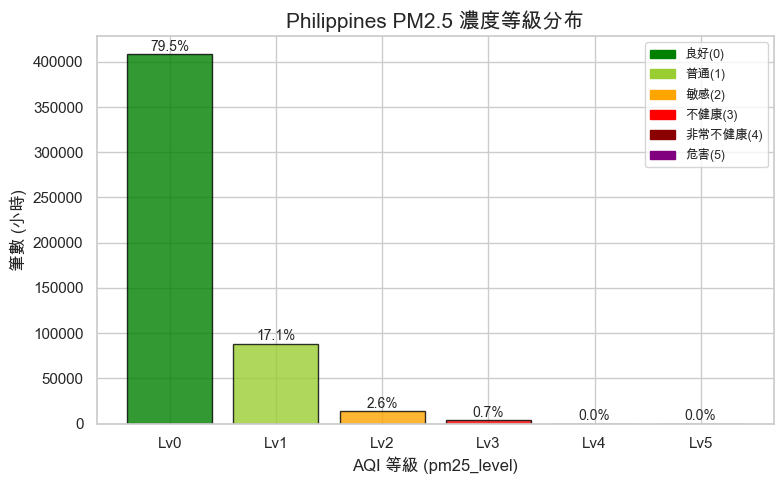

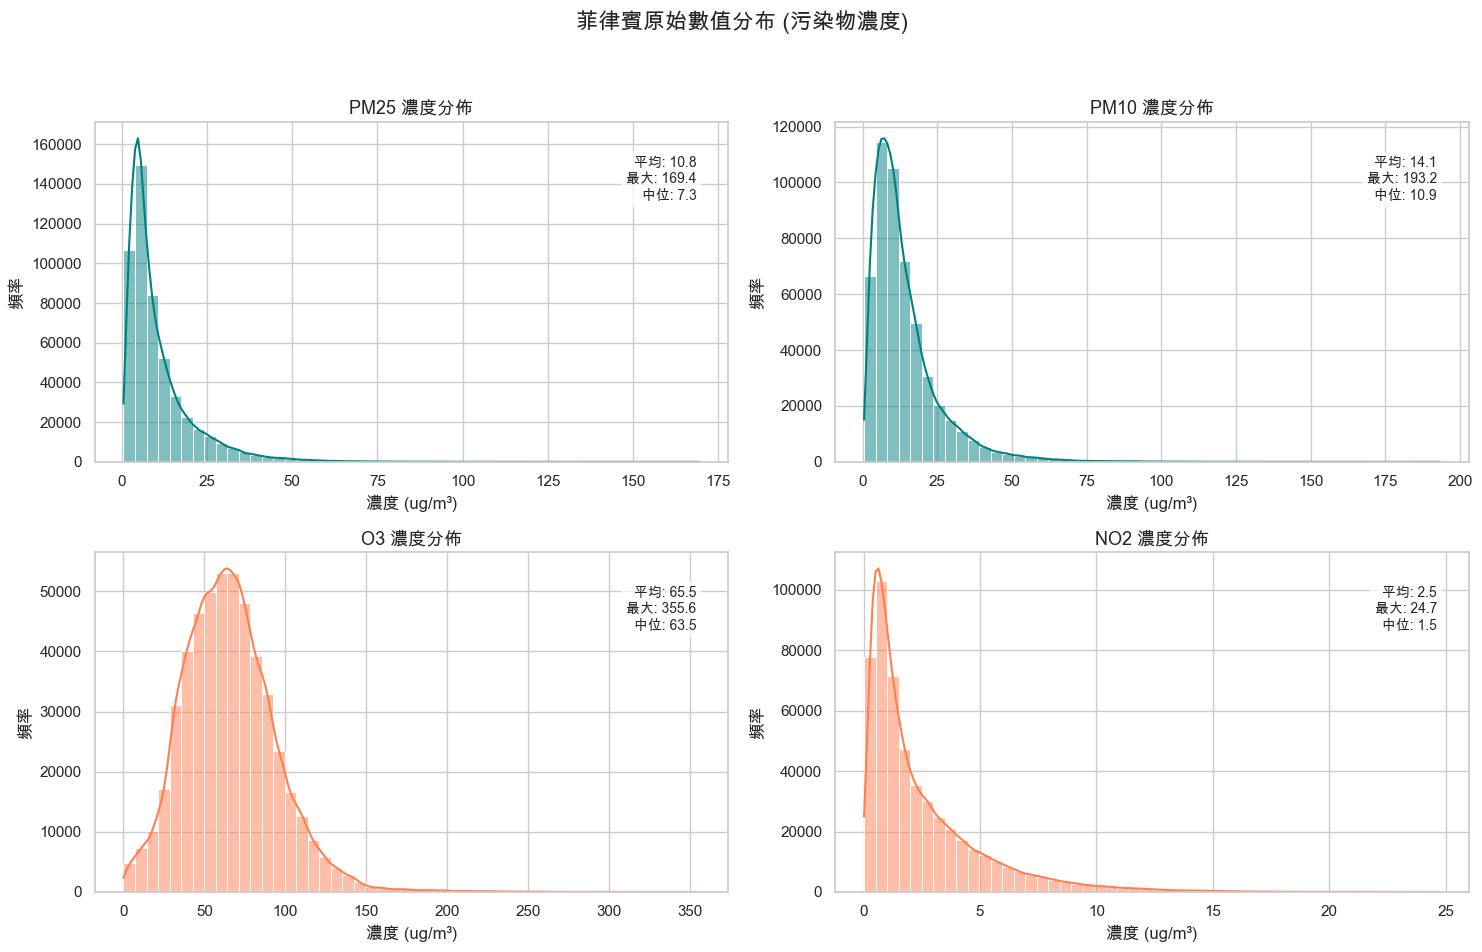


=== 菲律賓資料集統計摘要 ===


,項目,數值
0,總觀測小時數,"513,360"
1,測站(城市)數,138
2,時間起點,2026-01-01 00:00:00
3,時間終點,2026-06-04 23:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# ── 設定字體與顏色 (比照您提供的規格) ───────────────────────────
matplotlib.rcParams["font.family"] = "Arial Unicode MS"
label_names = ["良好(0)",
               
                "普通(1)", "敏感(2)", "不健康(3)", "非常不健康(4)", "危害(5)"]
colors      = ["green", "yellowgreen", "orange", "red", "darkred", "purple"]
aqi_labels  = [f"Lv{i}" for i in range(6)]

# ── 1. 菲律賓 AQI 六等級分布圖 ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

# 計算分布
sub = df_ph_clean["pm25_level"]
dist = sub.value_counts().sort_index().reindex(range(6), fill_value=0)
pct  = (dist / len(sub) * 100).round(1)

# 繪製長條圖
bars = ax.bar(range(6), dist.values, color=colors, edgecolor="black", alpha=0.8)
ax.set_title("Philippines PM2.5 濃度等級分布", fontsize=15, fontweight="bold")
ax.set_xticks(range(6))
ax.set_xticklabels(aqi_labels)
ax.set_xlabel("AQI 等級 (pm25_level)")
ax.set_ylabel("筆數 (小時)")

# 標註百分比
for i, (v, p) in enumerate(zip(dist.values, pct.values)):
    if v >= 0: # 即使是 0 也標註，或改 v > 0 只標註有資料的
        ax.text(i, v + dist.max() * 0.01, f"{p}%", ha="center", fontsize=10, fontweight="bold")

# 加入共用圖例
legend_patches = [plt.Rectangle((0,0),1,1, color=c) for c in colors]
ax.legend(legend_patches, label_names, loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

# ── 2. 四種污染物數值分布圖 (直方圖) ─────────────────────────────
pollutants = ["pm25", "pm10", "o3", "no2"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plt.suptitle("菲律賓原始數值分布 (污染物濃度)", fontsize=16, fontweight="bold", y=0.98)

for i, pol in enumerate(pollutants):
    ax = axes[i//2, i%2]
    # 使用與 AQI 對應的色系作為主色
    main_color = "teal" if "pm" in pol else "coral"
    
    sns.histplot(df_ph_clean[pol], bins=50, kde=True, ax=ax, color=main_color, edgecolor="white")
    
    # 標註統計資訊
    stats = df_ph_clean[pol].describe()
    stat_text = f"平均: {stats['mean']:.1f}\n最大: {stats['max']:.1f}\n中位: {stats['50%']:.1f}"
    ax.text(0.95, 0.90, stat_text, transform=ax.transAxes, verticalalignment='top', 
            horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7), fontsize=10)
    
    ax.set_title(f"{pol.upper()} 濃度分佈", fontsize=13)
    ax.set_xlabel("濃度 (ug/m³)")
    ax.set_ylabel("頻率")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# ── 3. 輸出文字統計表格 ─────────────────────────────────────────
print("\n=== 菲律賓資料集統計摘要 ===")
summary_df = pd.DataFrame({
    "項目": ["總觀測小時數", "測站(城市)數", "時間起點", "時間終點"],
    "數值": [f"{len(df_ph_clean):,}", df_ph_clean['station'].nunique(), 
            df_ph_clean['datetime'].min(), df_ph_clean['datetime'].max()]
})
display(summary_df)


  資料集：Beijing


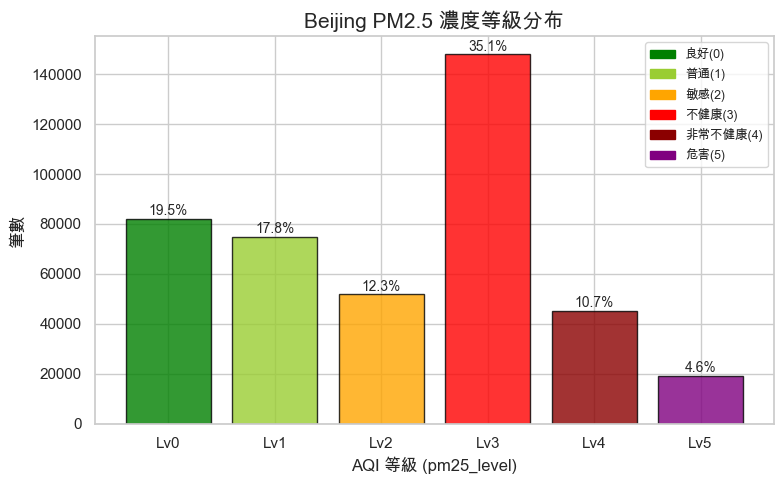

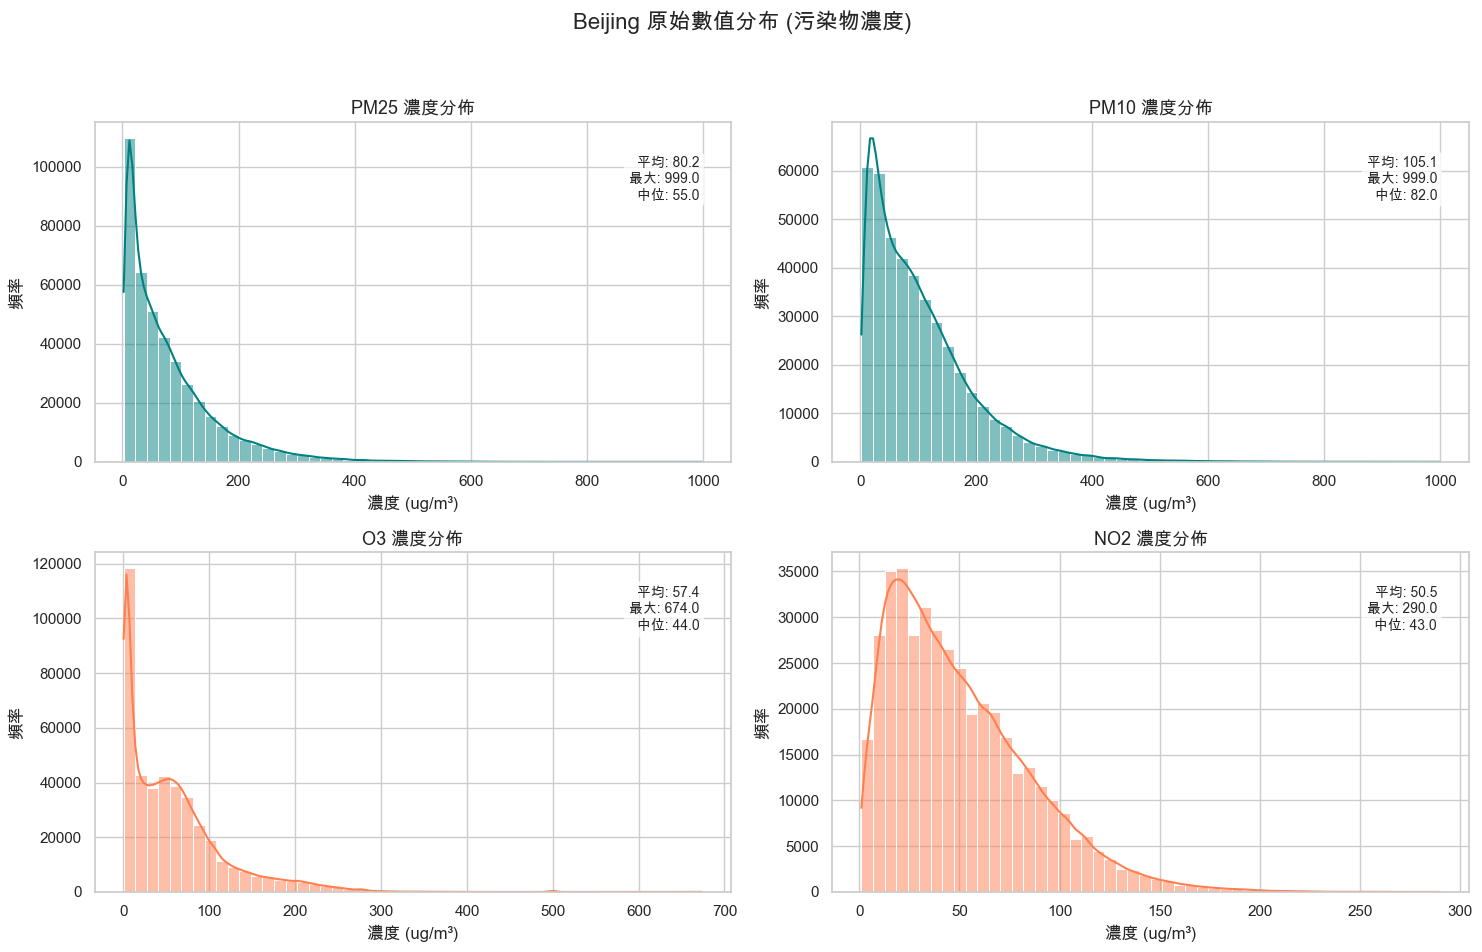


=== Beijing 資料集統計摘要 ===


,項目,數值
0,總觀測筆數,"420,746"
1,測站(城市)數,12
2,時間起點,2013-03-01 00:00:00
3,時間終點,2017-02-28 23:00:00



  資料集：India


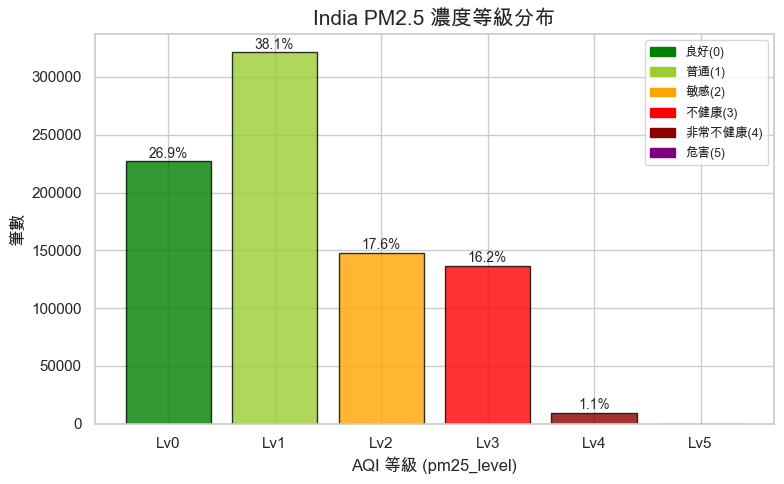

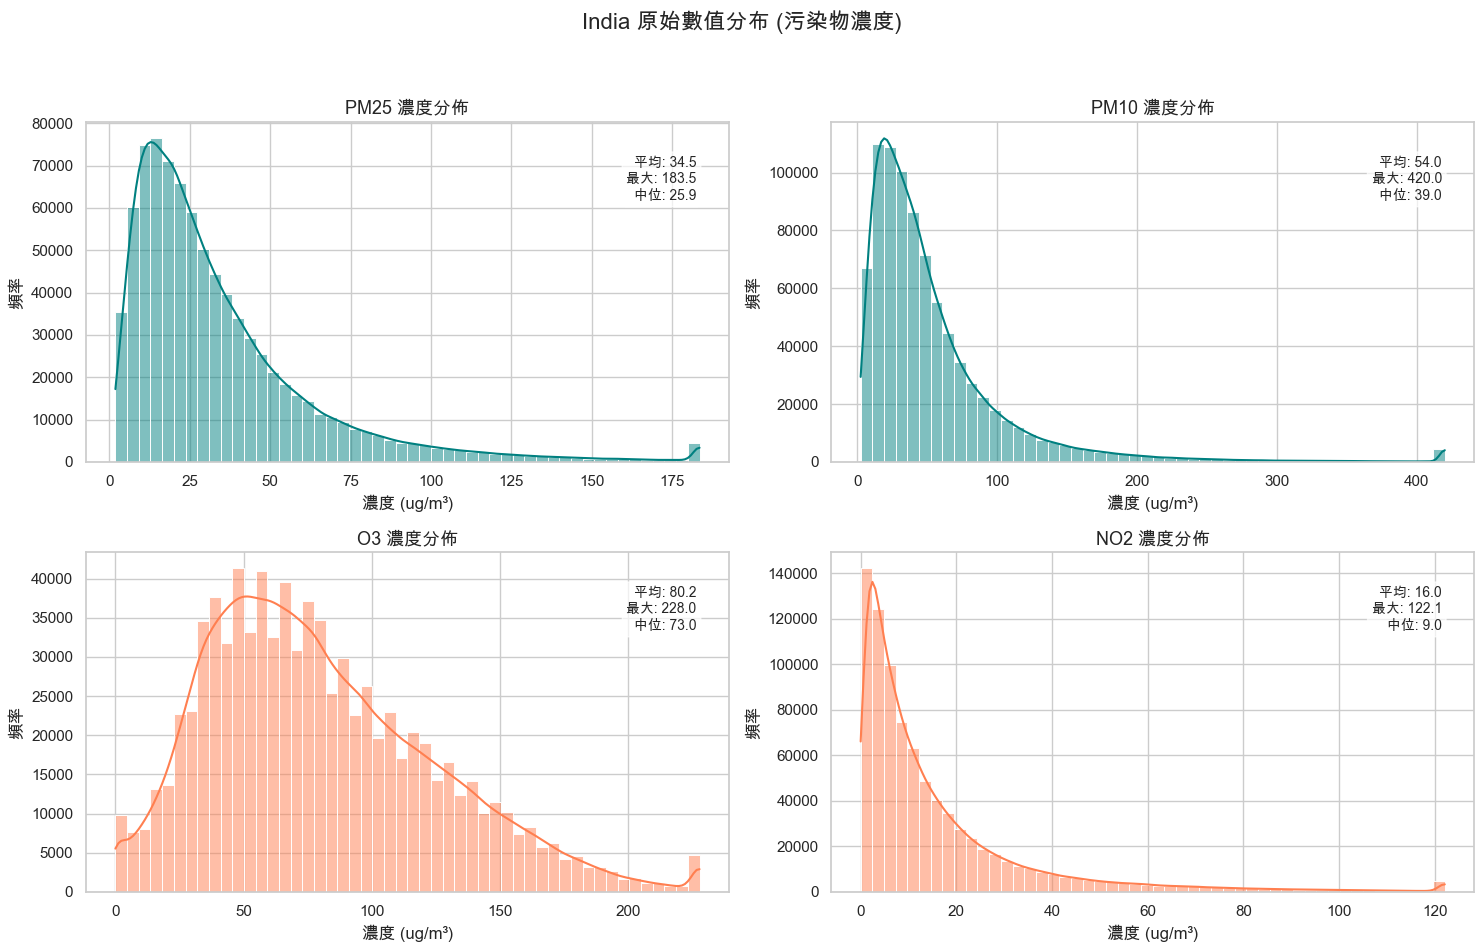


=== India 資料集統計摘要 ===


,項目,數值
0,總觀測筆數,"842,160"
1,測站(城市)數,29
2,時間起點,2022-08-05 00:00:00
3,時間終點,2025-11-26 23:00:00



  資料集：Taiwan


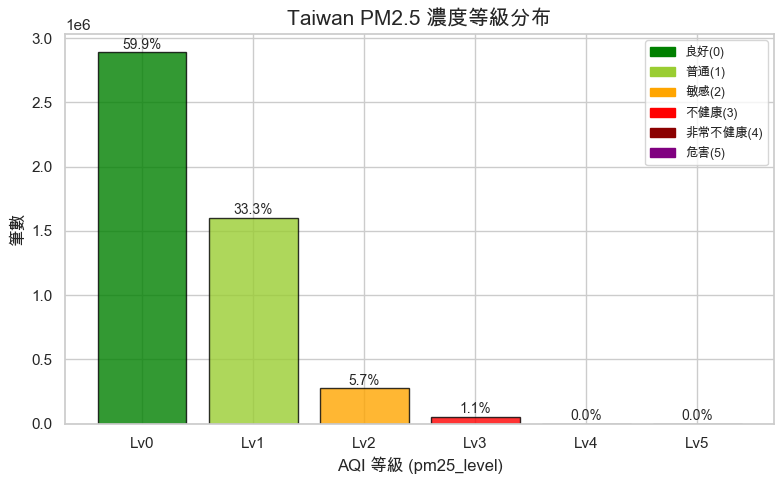

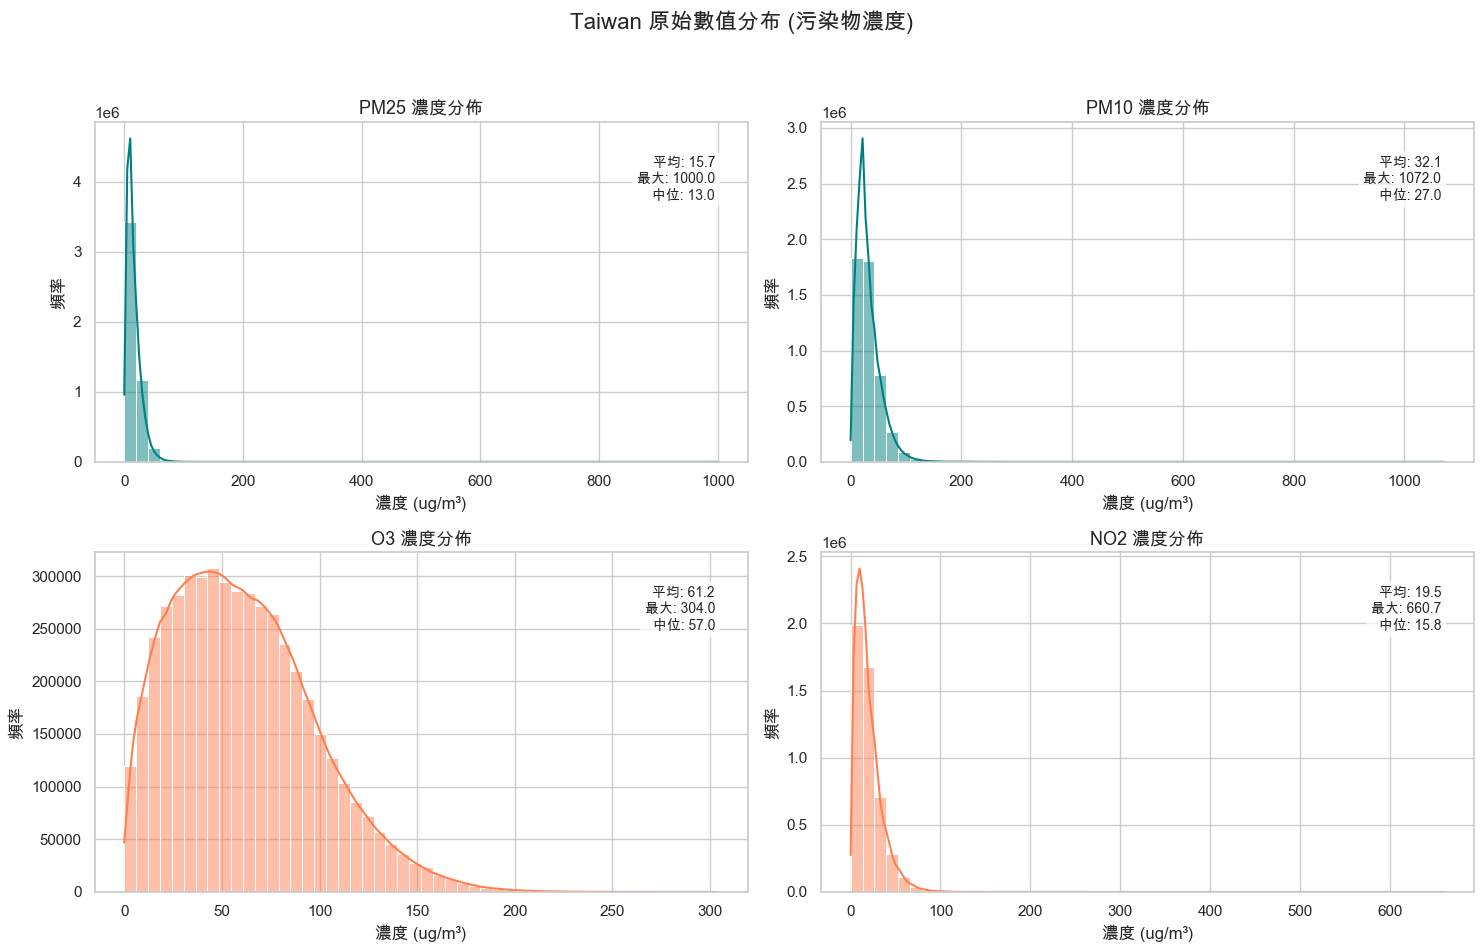


=== Taiwan 資料集統計摘要 ===


,項目,數值
0,總觀測筆數,"4,821,046"
1,測站(城市)數,107
2,時間起點,2018-03-26 15:00:00
3,時間終點,2024-08-31 23:00:00



  資料集：Seoul


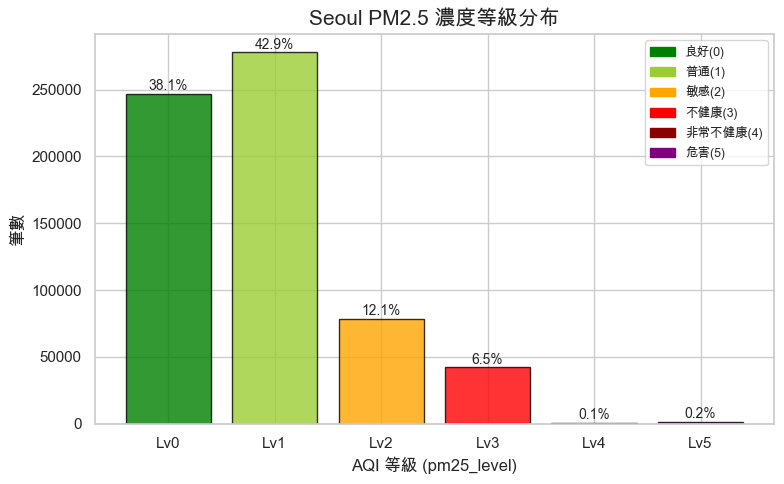

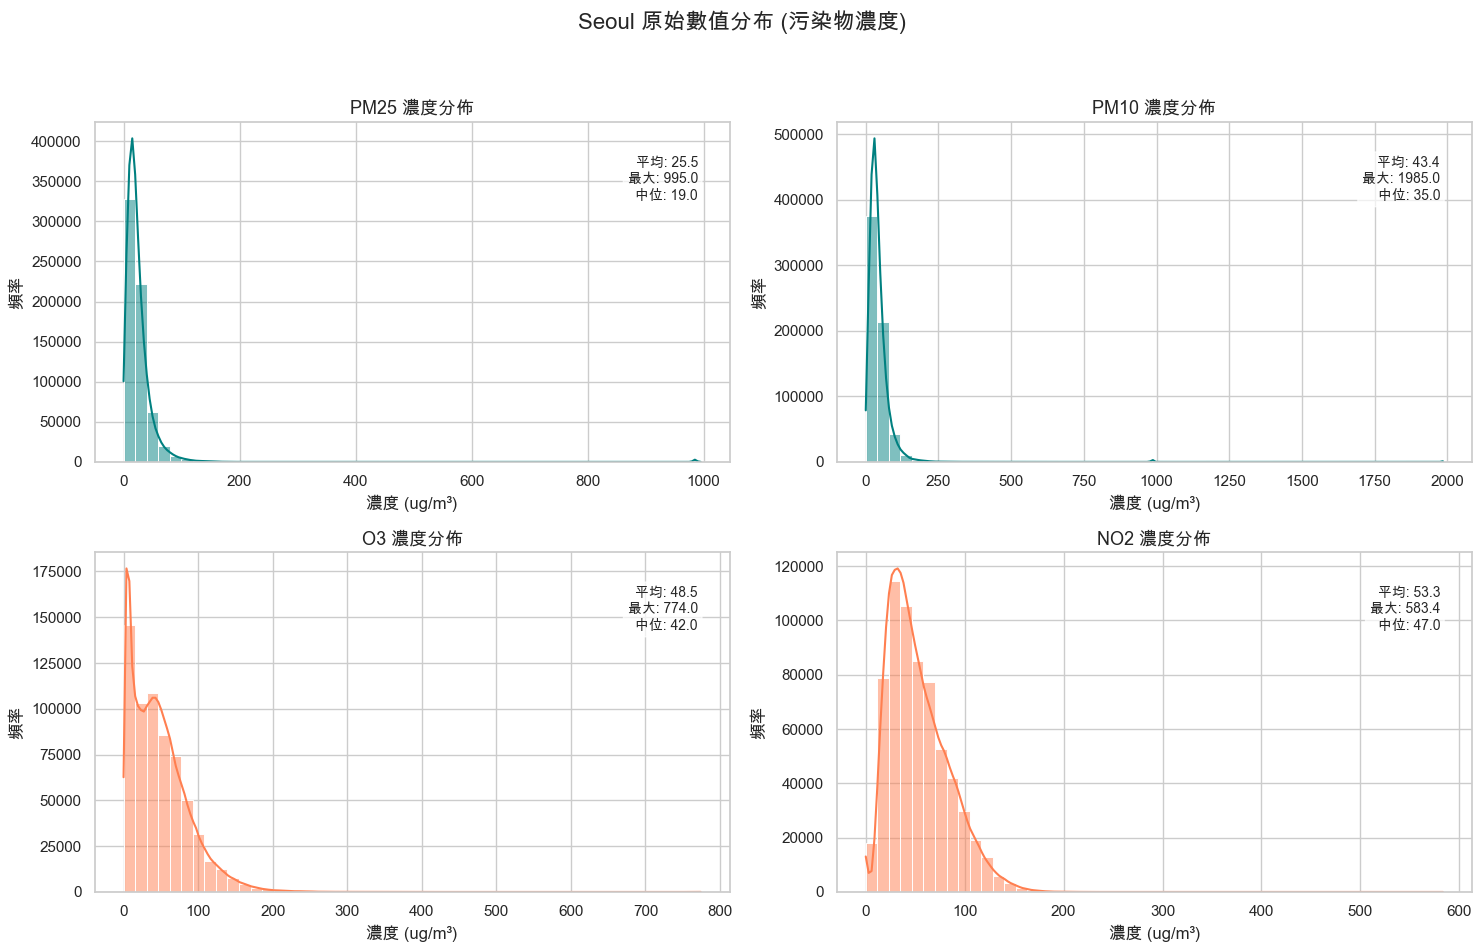


=== Seoul 資料集統計摘要 ===


,項目,數值
0,總觀測筆數,"647,511"
1,測站(城市)數,25
2,時間起點,2017-01-01 00:00:00
3,時間終點,2019-12-31 23:00:00



  資料集：Japan


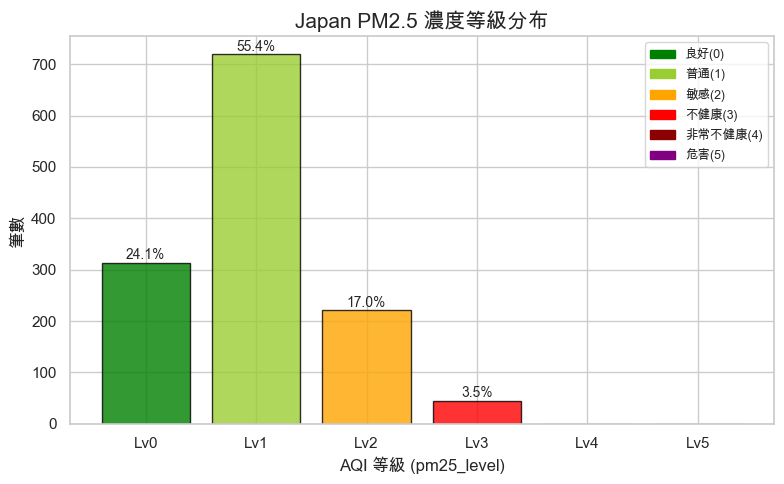

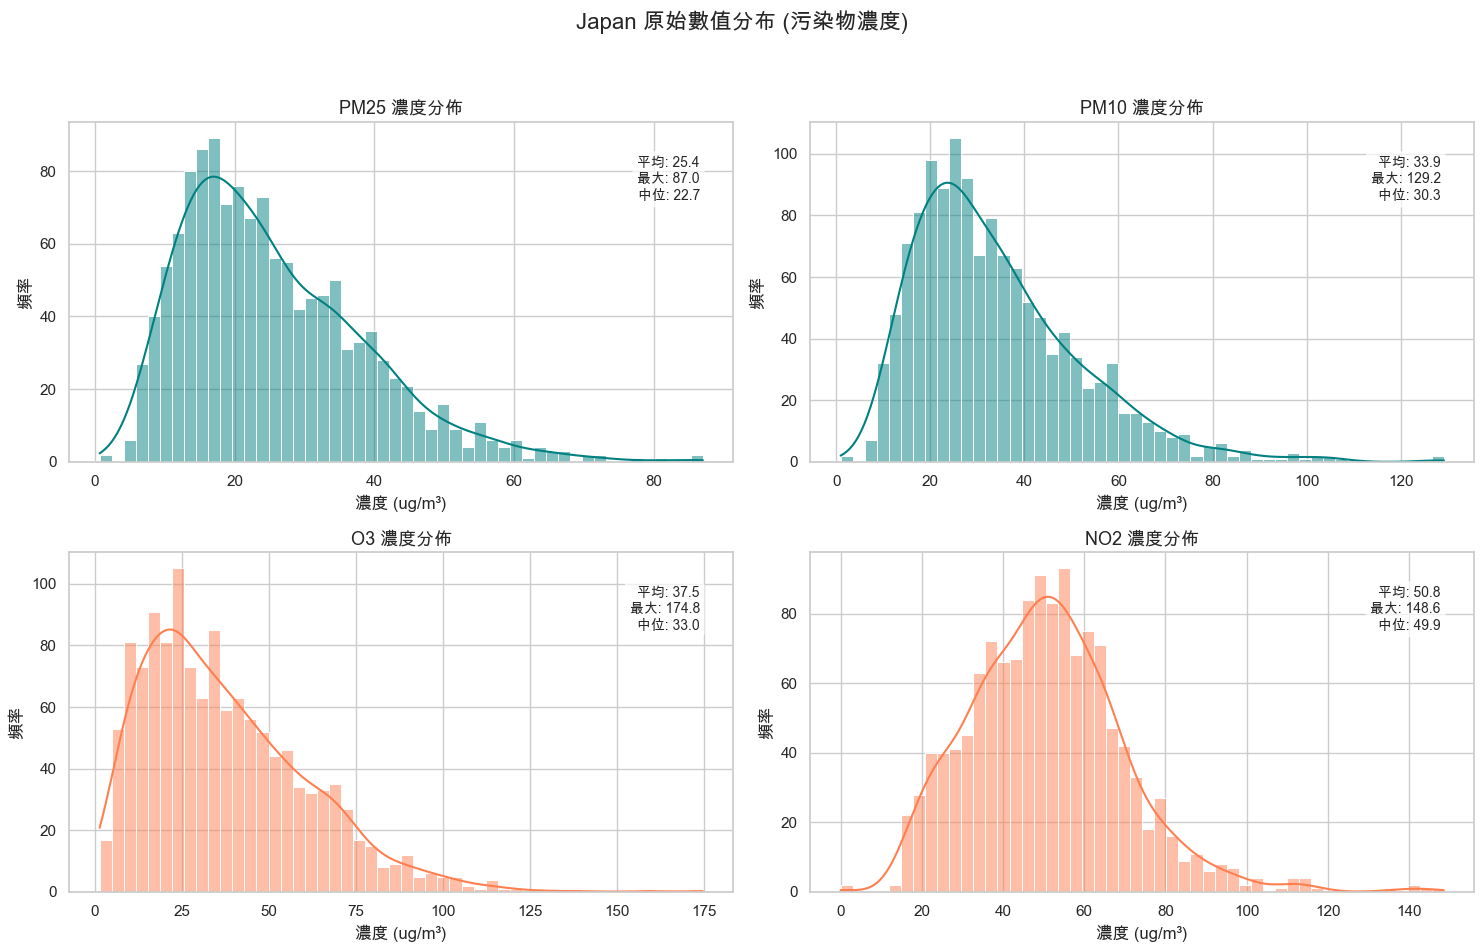


=== Japan 資料集統計摘要 ===


,項目,數值
0,總觀測筆數,"1,298"
1,測站(城市)數,1
2,時間起點,2022-08-01
3,時間終點,2026-02-18



  資料集：Philippines


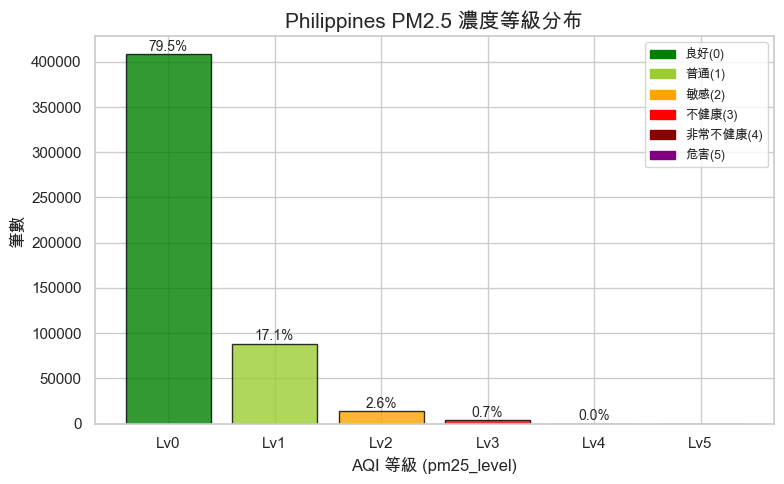

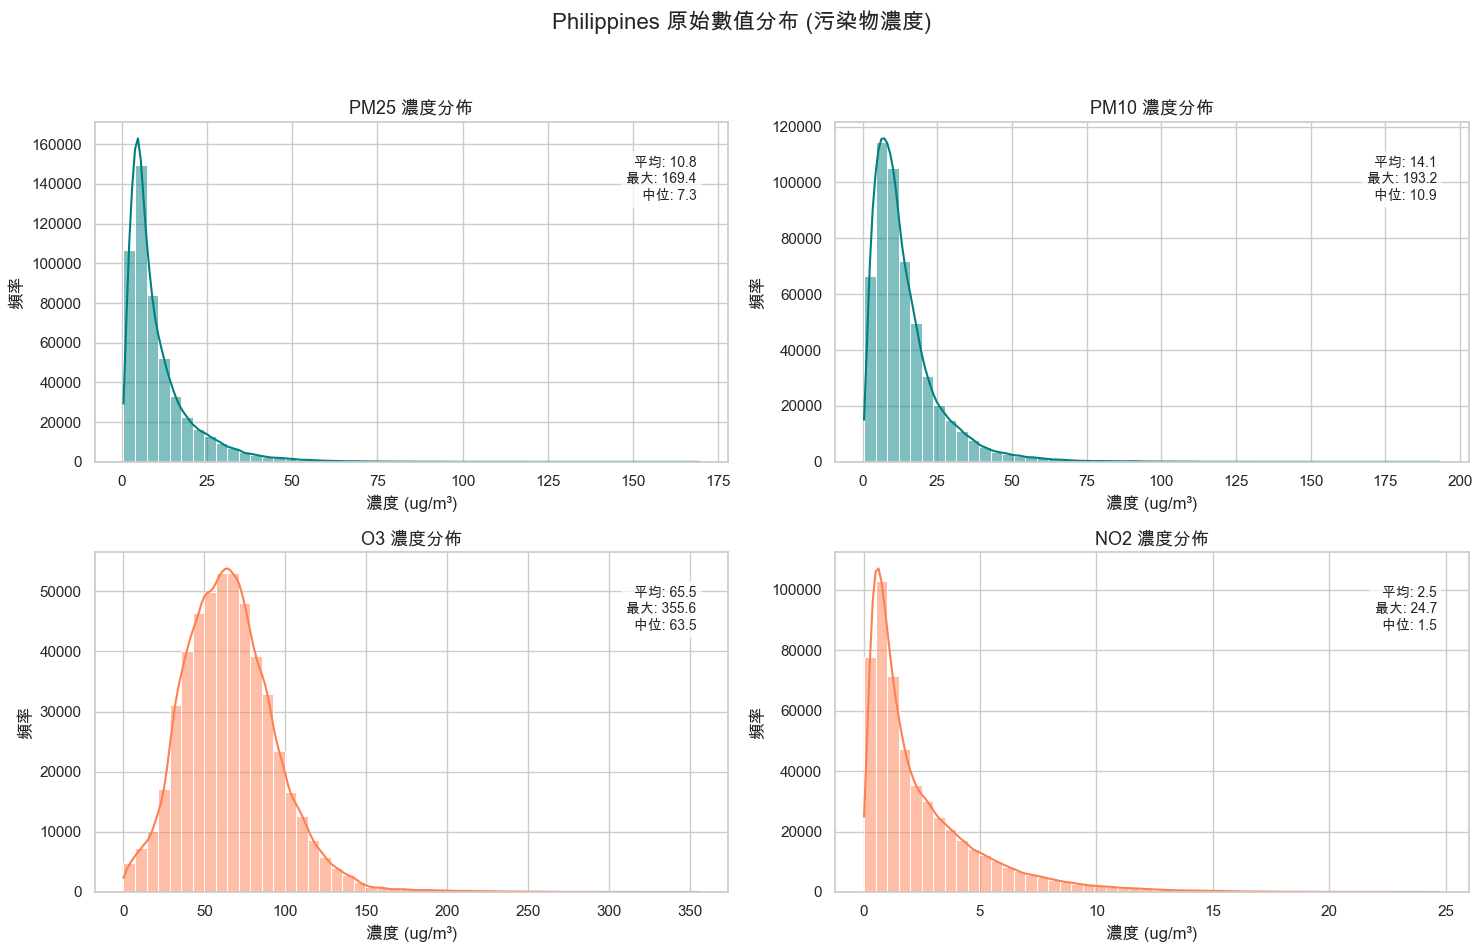


=== Philippines 資料集統計摘要 ===


,項目,數值
0,總觀測筆數,"513,360"
1,測站(城市)數,138
2,時間起點,2026-01-01 00:00:00
3,時間終點,2026-06-04 23:00:00


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams["font.family"] = "Arial Unicode MS"
label_names = ["良好(0)", "普通(1)", "敏感(2)", "不健康(3)", "非常不健康(4)", "危害(5)"]
colors      = ["green", "yellowgreen", "orange", "red", "darkred", "purple"]
aqi_labels  = [f"Lv{i}" for i in range(6)]
pollutants  = ["pm25", "pm10", "o3", "no2"]

# ── 載入所有資料集 ──────────────────────────────────────────────
df_main = pd.read_csv("../data/Cross-Domain Air Pollution Prediction.csv",
                      dtype={"station": str})
df_jp   = pd.read_csv("../data/japan_processed.csv", dtype={"station": str})

datasets = {
    "Beijing":     df_main[df_main["source"] == "beijing"].copy(),
    "India":       df_main[df_main["source"] == "india"].copy(),
    "Taiwan":      df_main[df_main["source"] == "taiwan"].copy(),
    "Seoul":       df_main[df_main["source"] == "seoul"].copy(),
    "Japan":       df_jp.copy(),
    "Philippines": df_ph_clean.copy(),
}

for name, df in datasets.items():
    print(f"\n{'='*60}")
    print(f"  資料集：{name}")
    print(f"{'='*60}")

    # ── 1. PM2.5 六等級分布圖 ────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))
    sub  = df["pm25_level"].dropna()
    dist = sub.value_counts().sort_index().reindex(range(6), fill_value=0)
    pct  = (dist / len(sub) * 100).round(1)

    ax.bar(range(6), dist.values, color=colors, edgecolor="black", alpha=0.8)
    ax.set_title(f"{name} PM2.5 濃度等級分布", fontsize=15, fontweight="bold")
    ax.set_xticks(range(6))
    ax.set_xticklabels(aqi_labels)
    ax.set_xlabel("AQI 等級 (pm25_level)")
    ax.set_ylabel("筆數")

    for i, (v, p) in enumerate(zip(dist.values, pct.values)):
        if v > 0:
            ax.text(i, v + dist.max() * 0.01, f"{p}%", ha="center", fontsize=10, fontweight="bold")

    legend_patches = [plt.Rectangle((0,0),1,1, color=c) for c in colors]
    ax.legend(legend_patches, label_names, loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.show()

    # ── 2. 四種污染物直方圖 ──────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    plt.suptitle(f"{name} 原始數值分布 (污染物濃度)", fontsize=16, fontweight="bold", y=0.98)

    for i, pol in enumerate(pollutants):
        ax = axes[i//2, i%2]
        main_color = "teal" if "pm" in pol else "coral"
        sns.histplot(df[pol].dropna(), bins=50, kde=True, ax=ax,
                     color=main_color, edgecolor="white")
        stats = df[pol].describe()
        stat_text = f"平均: {stats['mean']:.1f}\n最大: {stats['max']:.1f}\n中位: {stats['50%']:.1f}"
        ax.text(0.95, 0.90, stat_text, transform=ax.transAxes,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7), fontsize=10)
        ax.set_title(f"{pol.upper()} 濃度分佈", fontsize=13)
        ax.set_xlabel("濃度 (ug/m³)")
        ax.set_ylabel("頻率")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # ── 3. 統計摘要表 ────────────────────────────────────────────
    print(f"\n=== {name} 資料集統計摘要 ===")
    summary_df = pd.DataFrame({
        "項目": ["總觀測筆數", "測站(城市)數", "時間起點", "時間終點"],
        "數值": [
            f"{len(df):,}",
            df["station"].nunique(),
            df["datetime"].min(),
            df["datetime"].max(),
        ]
    })
    display(summary_df)
